In [11]:
# ============================================================
# AGRIMIND — PLANTVILLAGE LOADER DIAGNOSTIC
# ============================================================

from datasets import load_dataset
from collections import Counter

print("=" * 80)
print("AGRIMIND — PLANTVILLAGE DATASET DIAGNOSTIC")
print("=" * 80)

# ------------------------------------------------------------
# 1. LOAD THE ONLY AVAILABLE CONFIGURATION
# ------------------------------------------------------------

print("\n[1/6] Loading dataset...")

ds = load_dataset("mohanty/PlantVillage", "default")

print("✓ Dataset loaded successfully")
print(ds)

# ------------------------------------------------------------
# 2. SPLIT INFORMATION
# ------------------------------------------------------------

print("\n[2/6] SPLIT INFORMATION")
print("-" * 80)

for split in ds:
    print(f"{split}: {len(ds[split]):,} rows")

# ------------------------------------------------------------
# 3. FEATURES
# ------------------------------------------------------------

print("\n[3/6] FEATURES")
print("-" * 80)

features = ds["train"].features

for name, feature in features.items():
    print(f"{name}: {feature}")

# ------------------------------------------------------------
# 4. SAMPLE RECORDS
# ------------------------------------------------------------

print("\n[4/6] SAMPLE RECORDS")
print("-" * 80)

for i in range(min(5, len(ds["train"]))):
    print(f"\n--- Sample {i} ---")
    print(ds["train"][i])

# ------------------------------------------------------------
# 5. TEXT FORMAT ANALYSIS
# ------------------------------------------------------------

print("\n[5/6] TEXT FORMAT ANALYSIS")
print("-" * 80)

if "text" in features:

    samples = ds["train"]["text"][:10]

    print("First 10 text records:\n")

    for i, text in enumerate(samples):
        print(f"{i}: {text}")

else:
    print("No 'text' column found.")

# ------------------------------------------------------------
# 6. SUMMARY
# ------------------------------------------------------------

print("\n[6/6] DIAGNOSTIC SUMMARY")
print("-" * 80)

print(f"Train rows : {len(ds['train']):,}")
print(f"Test rows  : {len(ds['test']):,}")
print(f"Features   : {list(features.keys())}")

if "text" in features:
    print("\n⚠️ IMPORTANT:")
    print("The current Hugging Face loader is exposing PlantVillage")
    print("as TEXT/MANIFEST records rather than decoded image records.")
    print()
    print("Therefore we should NOT start MobileNet training yet.")
    print("We first need to resolve how these records point to the")
    print("actual PlantVillage images.")

print("\n" + "=" * 80)
print("DIAGNOSTIC COMPLETE")
print("=" * 80)

AGRIMIND — PLANTVILLAGE DATASET DIAGNOSTIC

[1/6] Loading dataset...
✓ Dataset loaded successfully
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 129783
    })
    test: Dataset({
        features: ['text'],
        num_rows: 33133
    })
})

[2/6] SPLIT INFORMATION
--------------------------------------------------------------------------------
train: 129,783 rows
test: 33,133 rows

[3/6] FEATURES
--------------------------------------------------------------------------------
text: Value('string')

[4/6] SAMPLE RECORDS
--------------------------------------------------------------------------------

--- Sample 0 ---
{'text': 'raw/color/Raspberry___healthy/a37f34f7-022d-461a-8a3d-95f5cd774e35___Mary_HL 9155.JPG'}

--- Sample 1 ---
{'text': 'raw/color/Raspberry___healthy/368f3c83-5bd2-4906-b418-57b6ceff9bfe___Mary_HL 9160.JPG'}

--- Sample 2 ---
{'text': 'raw/color/Raspberry___healthy/98226f66-15a1-40d5-9b62-04ae5b4fd8d5___Mary_HL 9159.JPG'}

--- Sampl

AGRIMIND — PLANTVILLAGE REAL IMAGE SETUP

[1/9] Configuration
--------------------------------------------------------------------------------
Repository : mohanty/PlantVillage
Base dir   : /content/agrimind_plantvillage
Data dir   : /content/agrimind_plantvillage/data

[2/9] Downloading PlantVillage data.zip
--------------------------------------------------------------------------------
This may take some time depending on Colab bandwidth.


data.zip:   0%|          | 0.00/2.18G [00:00<?, ?B/s]

✓ Download complete:
/content/agrimind_plantvillage/download/data.zip

[3/9] Extracting dataset
--------------------------------------------------------------------------------
Extracting data.zip...
Files in archive: 163,034
✓ Extraction complete

[4/9] Locating color image directory
--------------------------------------------------------------------------------
✓ Color dataset found:
/content/agrimind_plantvillage/data/raw/color

[5/9] Downloading official split manifests
--------------------------------------------------------------------------------
Train manifest: /content/agrimind_plantvillage/download/splits/color_train.txt
Test manifest : /content/agrimind_plantvillage/download/splits/color_test.txt

[6/9] Resolving image paths
--------------------------------------------------------------------------------
Manifest train entries: 43,596
Manifest test entries : 10,709

Resolved images:
Train: 43,596
Test : 10,709

Missing:
Train: 0
Test : 0

[7/9] Extracting disease classes
--

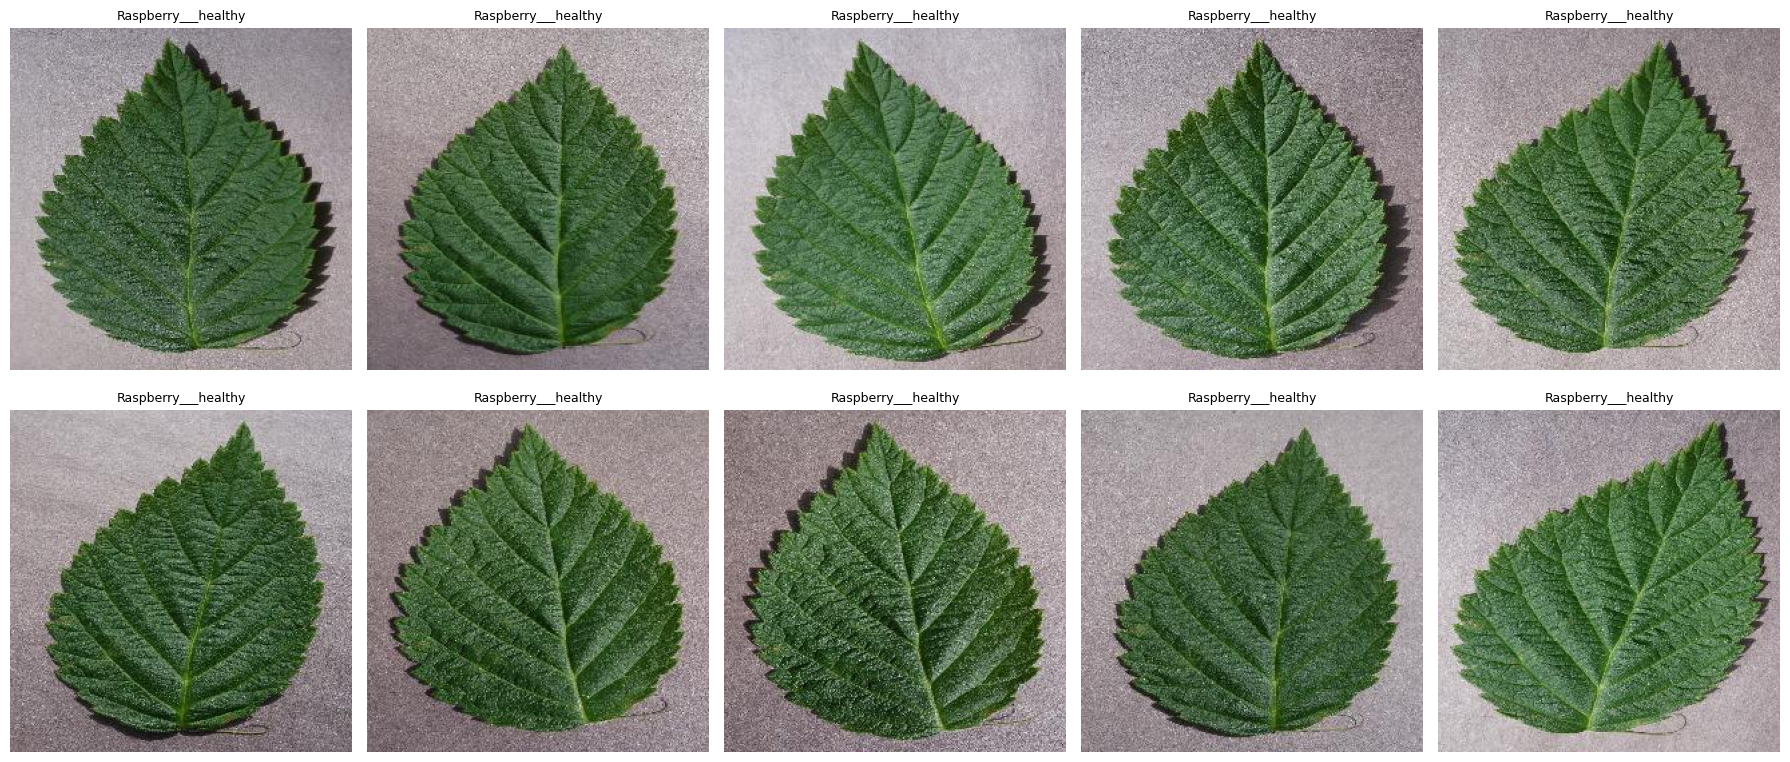



AGRIMIND — PLANTVILLAGE DATASET READY

Dataset:
    mohanty/PlantVillage

Image configuration:
    COLOR / RGB

Train images:
    43,596

Test images:
    10,709

Disease/crop classes:
    38

Missing train images:
    0

Missing test images:
    0

Color directory:
    /content/agrimind_plantvillage/data/raw/color

STATUS: ✓ ALL MANIFEST IMAGES RESOLVED

Class mapping saved to:
/content/agrimind_plantvillage/class_mapping.json

SETUP COMPLETE — DO NOT START TRAINING YET


In [13]:
# ============================================================
# AGRIMIND — PLANTVILLAGE REAL IMAGE DATASET SETUP
# ============================================================
#
# This bypasses the Hugging Face manifest-only loader and
# downloads the actual PlantVillage image archive.
#
# Dataset:
#   mohanty/PlantVillage
#
# We use:
#   raw/color/
#
# Official splits:
#   splits/color_train.txt
#   splits/color_test.txt
#
# ============================================================

import os
import zipfile
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Hugging Face file downloader
from huggingface_hub import hf_hub_download

print("=" * 80)
print("AGRIMIND — PLANTVILLAGE REAL IMAGE SETUP")
print("=" * 80)


# ============================================================
# 1. CONFIGURATION
# ============================================================

REPO_ID = "mohanty/PlantVillage"
REPO_TYPE = "dataset"

BASE_DIR = Path("/content/agrimind_plantvillage")
ZIP_DIR = BASE_DIR / "download"
DATA_DIR = BASE_DIR / "data"

ZIP_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_ZIP = ZIP_DIR / "data.zip"

print("\n[1/9] Configuration")
print("-" * 80)
print(f"Repository : {REPO_ID}")
print(f"Base dir   : {BASE_DIR}")
print(f"Data dir   : {DATA_DIR}")


# ============================================================
# 2. DOWNLOAD ACTUAL DATASET ARCHIVE
# ============================================================

print("\n[2/9] Downloading PlantVillage data.zip")
print("-" * 80)

if DATA_ZIP.exists():
    print("✓ data.zip already exists")
else:
    print("Downloading approximately 2+ GB...")
    print("This may take some time depending on Colab bandwidth.")

    downloaded_path = hf_hub_download(
        repo_id=REPO_ID,
        filename="data.zip",
        repo_type=REPO_TYPE,
        local_dir=str(ZIP_DIR)
    )

    print(f"✓ Download complete:")
    print(downloaded_path)


# ============================================================
# 3. EXTRACT DATASET
# ============================================================

print("\n[3/9] Extracting dataset")
print("-" * 80)

EXTRACT_MARKER = DATA_DIR / ".extracted"

if EXTRACT_MARKER.exists():
    print("✓ Dataset already extracted")
else:

    print("Extracting data.zip...")

    with zipfile.ZipFile(DATA_ZIP, "r") as z:
        members = z.namelist()

        print(f"Files in archive: {len(members):,}")

        z.extractall(DATA_DIR)

    EXTRACT_MARKER.touch()

    print("✓ Extraction complete")


# ============================================================
# 4. LOCATE RAW/COLOR DIRECTORY
# ============================================================

print("\n[4/9] Locating color image directory")
print("-" * 80)

possible_paths = [
    DATA_DIR / "raw" / "color",
    DATA_DIR / "data" / "raw" / "color",
]

COLOR_DIR = None

for path in possible_paths:
    if path.exists() and path.is_dir():
        COLOR_DIR = path
        break

# More robust fallback search
if COLOR_DIR is None:

    matches = list(DATA_DIR.rglob("raw/color"))

    if matches:
        COLOR_DIR = matches[0]

if COLOR_DIR is None:
    raise FileNotFoundError(
        "Could not locate raw/color after extracting data.zip."
    )

print(f"✓ Color dataset found:")
print(COLOR_DIR)


# ============================================================
# 5. DOWNLOAD OFFICIAL TRAIN/TEST MANIFESTS
# ============================================================

print("\n[5/9] Downloading official split manifests")
print("-" * 80)

TRAIN_MANIFEST = ZIP_DIR / "color_train.txt"
TEST_MANIFEST = ZIP_DIR / "color_test.txt"

if not TRAIN_MANIFEST.exists():

    hf_hub_download(
        repo_id=REPO_ID,
        filename="splits/color_train.txt",
        repo_type=REPO_TYPE,
        local_dir=str(ZIP_DIR)
    )

    # Depending on huggingface_hub version, this may create:
    # ZIP_DIR/splits/color_train.txt
    possible = [
        ZIP_DIR / "splits" / "color_train.txt",
        ZIP_DIR / "color_train.txt"
    ]

    for p in possible:
        if p.exists():
            TRAIN_MANIFEST = p
            break

if not TEST_MANIFEST.exists():

    hf_hub_download(
        repo_id=REPO_ID,
        filename="splits/color_test.txt",
        repo_type=REPO_TYPE,
        local_dir=str(ZIP_DIR)
    )

    possible = [
        ZIP_DIR / "splits" / "color_test.txt",
        ZIP_DIR / "color_test.txt"
    ]

    for p in possible:
        if p.exists():
            TEST_MANIFEST = p
            break


print("Train manifest:", TRAIN_MANIFEST)
print("Test manifest :", TEST_MANIFEST)


# ============================================================
# 6. READ MANIFESTS AND RESOLVE IMAGE PATHS
# ============================================================

print("\n[6/9] Resolving image paths")
print("-" * 80)


def read_manifest(manifest_path):

    with open(manifest_path, "r", encoding="utf-8") as f:
        return [
            line.strip()
            for line in f
            if line.strip()
        ]


train_entries = read_manifest(TRAIN_MANIFEST)
test_entries = read_manifest(TEST_MANIFEST)

print(f"Manifest train entries: {len(train_entries):,}")
print(f"Manifest test entries : {len(test_entries):,}")


# ------------------------------------------------------------
# Resolve paths
# ------------------------------------------------------------

def resolve_image_path(entry):

    # Manifest entry example:
    #
    # raw/color/Raspberry___healthy/image.JPG

    entry_path = Path(entry)

    # Try relative to extracted dataset root
    candidate = DATA_DIR / entry

    if candidate.exists():
        return candidate

    # Try relative to parent of raw
    candidate = COLOR_DIR.parent.parent / entry_path

    if candidate.exists():
        return candidate

    # Search by filename as fallback
    filename = entry_path.name

    matches = list(DATA_DIR.rglob(filename))

    if matches:
        return matches[0]

    return None


train_paths = []
test_paths = []

missing_train = []
missing_test = []


for entry in train_entries:

    path = resolve_image_path(entry)

    if path is not None:
        train_paths.append(path)
    else:
        missing_train.append(entry)


for entry in test_entries:

    path = resolve_image_path(entry)

    if path is not None:
        test_paths.append(path)
    else:
        missing_test.append(entry)


print("\nResolved images:")
print(f"Train: {len(train_paths):,}")
print(f"Test : {len(test_paths):,}")

print("\nMissing:")
print(f"Train: {len(missing_train):,}")
print(f"Test : {len(missing_test):,}")


if len(missing_train) > 0:
    print("\nFirst missing train file:")
    print(missing_train[0])

if len(missing_test) > 0:
    print("\nFirst missing test file:")
    print(missing_test[0])


# ============================================================
# 7. EXTRACT CLASS LABELS FROM DIRECTORY/PATH
# ============================================================

print("\n[7/9] Extracting disease classes")
print("-" * 80)


def extract_class(entry):

    # raw/color/CLASS_NAME/file.jpg

    parts = entry.replace("\\", "/").split("/")

    try:
        color_index = parts.index("color")
        return parts[color_index + 1]
    except ValueError:

        # Fallback
        for part in parts:
            if "___" in part:
                return part

    return "UNKNOWN"


train_labels = [
    extract_class(entry)
    for entry in train_entries
    if resolve_image_path(entry) is not None
]

test_labels = [
    extract_class(entry)
    for entry in test_entries
    if resolve_image_path(entry) is not None
]


classes = sorted(
    set(train_labels) |
    set(test_labels)
)

class_to_idx = {
    cls: idx
    for idx, cls in enumerate(classes)
}

idx_to_class = {
    idx: cls
    for cls, idx in class_to_idx.items()
}


print(f"\nNumber of classes: {len(classes)}")

for idx, cls in idx_to_class.items():
    print(f"{idx:02d} -> {cls}")


# ============================================================
# 8. CLASS DISTRIBUTION
# ============================================================

print("\n[8/9] CLASS DISTRIBUTION")
print("-" * 80)

train_counter = Counter(train_labels)
test_counter = Counter(test_labels)

print(
    f"{'ID':<5}"
    f"{'CLASS':<55}"
    f"{'TRAIN':>10}"
    f"{'TEST':>10}"
    f"{'TOTAL':>10}"
)

print("-" * 90)

for idx, cls in idx_to_class.items():

    tr = train_counter.get(cls, 0)
    te = test_counter.get(cls, 0)

    print(
        f"{idx:<5}"
        f"{cls:<55}"
        f"{tr:>10,}"
        f"{te:>10,}"
        f"{tr + te:>10,}"
    )


# ============================================================
# 9. VERIFY ACTUAL IMAGES + DISPLAY SAMPLES
# ============================================================

print("\n[9/9] Verifying actual images")
print("-" * 80)

sample_count = min(10, len(train_paths))

valid_images = []

for i in range(sample_count):

    path = train_paths[i]

    try:

        image = Image.open(path)
        image.load()

        valid_images.append(
            (
                image.copy(),
                extract_class(train_entries[i]),
                path
            )
        )

        image.close()

    except Exception as e:

        print(f"ERROR: {path}")
        print(e)


print(f"✓ Successfully opened {len(valid_images)}/{sample_count} sample images")


# ============================================================
# DISPLAY SAMPLE IMAGES
# ============================================================

if valid_images:

    print("\nDisplaying sample images...")

    cols = 5
    rows = int(np.ceil(len(valid_images) / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(18, 4 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for i, (image, label, path) in enumerate(valid_images):

        axes[i].imshow(image)

        axes[i].set_title(
            label,
            fontsize=9
        )

        axes[i].axis("off")

    for i in range(len(valid_images), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("AGRIMIND — PLANTVILLAGE DATASET READY")
print("=" * 80)

print(f"""
Dataset:
    {REPO_ID}

Image configuration:
    COLOR / RGB

Train images:
    {len(train_paths):,}

Test images:
    {len(test_paths):,}

Disease/crop classes:
    {len(classes)}

Missing train images:
    {len(missing_train):,}

Missing test images:
    {len(missing_test):,}

Color directory:
    {COLOR_DIR}
""")

if len(missing_train) == 0 and len(missing_test) == 0:

    print("STATUS: ✓ ALL MANIFEST IMAGES RESOLVED")

else:

    print("STATUS: ⚠ SOME IMAGES COULD NOT BE RESOLVED")


# ============================================================
# SAVE CLASS MAPPING
# ============================================================

import json

CLASS_MAP_FILE = BASE_DIR / "class_mapping.json"

with open(CLASS_MAP_FILE, "w", encoding="utf-8") as f:

    json.dump(
        {
            "class_to_idx": class_to_idx,
            "idx_to_class": {
                str(k): v
                for k, v in idx_to_class.items()
            }
        },
        f,
        indent=2
    )

print(f"\nClass mapping saved to:")
print(CLASS_MAP_FILE)

print("\n" + "=" * 80)
print("SETUP COMPLETE — DO NOT START TRAINING YET")
print("=" * 80)

In [4]:
# ================================================================
# AGRIMIND — COMPLETE PLANT DISEASE TRAINING PIPELINE
# GOOGLE COLAB / TESLA T4
#
# Dataset:
#   PlantVillage
#
# Source:
#   Official PlantVillage-Dataset GitHub repository
#
# Model:
#   MobileNetV3-Large
#
# IMPORTANT:
#   - NO HuggingFace load_dataset()
#   - NO obsolete data.zip URL
#   - Official train/test manifests
#   - Official test set kept untouched
#   - Validation split created only from official training set
#   - AgriMind confidence gate = 0.60
# ================================================================


# ================================================================
# 0. INSTALL PACKAGES
# ================================================================

!pip -q install scikit-learn pillow matplotlib seaborn tqdm pandas requests


# ================================================================
# 1. IMPORTS
# ================================================================

import os
import sys
import json
import time
import random
import shutil
import requests
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchvision

from torch import nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm.auto import tqdm


# ================================================================
# 2. CONFIGURATION
# ================================================================

SEED = 42

IMAGE_SIZE = 224

BATCH_SIZE = 64

EPOCHS = 15

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 1e-4

LABEL_SMOOTHING = 0.05

VAL_FRACTION = 0.10

PATIENCE = 4

CONFIDENCE_GATE = 0.60

NUM_WORKERS = 2


PROJECT = Path(
    "/content/agrimind_plantvillage"
)

DATA_DIR = (
    PROJECT /
    "data"
)

RAW_DIR = (
    DATA_DIR /
    "raw"
)

COLOR_DIR = (
    RAW_DIR /
    "color"
)

DOWNLOAD_DIR = (
    DATA_DIR /
    "download"
)

ARTIFACT_DIR = (
    PROJECT /
    "ml" /
    "artifacts"
)


for directory in [
    PROJECT,
    DATA_DIR,
    RAW_DIR,
    COLOR_DIR,
    DOWNLOAD_DIR,
    ARTIFACT_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ================================================================
# 3. RANDOM SEEDS
# ================================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False


# ================================================================
# 4. GPU CHECK
# ================================================================

print("=" * 70)
print("AGRIMIND — GPU CHECK")
print("=" * 70)

print(
    "PyTorch:",
    torch.__version__
)

print(
    "Torchvision:",
    torchvision.__version__
)

print(
    "CUDA:",
    torch.cuda.is_available()
)


if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA is unavailable. "
        "Enable T4 GPU in Colab."
    )


device = torch.device(
    "cuda"
)

print(
    "CUDA version:",
    torch.version.cuda
)

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

print(
    "VRAM:",
    round(
        torch.cuda.get_device_properties(
            0
        ).total_memory /
        (1024 ** 3),
        2
    ),
    "GB"
)

print("=" * 70)


# ================================================================
# 5. CURRENT PLANTVILLAGE REPOSITORY
# ================================================================

REPO_RAW = (
    "https://raw.githubusercontent.com/"
    "spMohanty/"
    "PlantVillage-Dataset/"
    "master/"
)


# ================================================================
# 6. DOWNLOAD OFFICIAL MANIFESTS
# ================================================================

print()
print("=" * 70)
print("DOWNLOADING OFFICIAL PLANTVILLAGE MANIFESTS")
print("=" * 70)


TRAIN_MANIFEST = (
    DOWNLOAD_DIR /
    "color_train.txt"
)

TEST_MANIFEST = (
    DOWNLOAD_DIR /
    "color_test.txt"
)


def download_file(
    url,
    destination
):

    destination = Path(
        destination
    )

    if destination.exists():

        print(
            "Already exists:",
            destination
        )

        return


    print(
        "Downloading:",
        url
    )


    response = requests.get(
        url,
        timeout=120
    )

    response.raise_for_status()


    destination.write_bytes(
        response.content
    )


    print(
        "Saved:",
        destination
    )


download_file(

    REPO_RAW +
    "download/splits/color_train.txt",

    TRAIN_MANIFEST

)


download_file(

    REPO_RAW +
    "download/splits/color_test.txt",

    TEST_MANIFEST

)


# ================================================================
# 7. READ MANIFESTS
# ================================================================

def read_manifest(
    path
):

    return [

        line.strip()

        for line in Path(
            path
        ).read_text().splitlines()

        if line.strip()

    ]


train_entries = read_manifest(
    TRAIN_MANIFEST
)

test_entries = read_manifest(
    TEST_MANIFEST
)


print()
print(
    "Official train entries:",
    len(train_entries)
)

print(
    "Official test entries:",
    len(test_entries)
)


# ================================================================
# 8. DATASET DOWNLOAD STRATEGY
# ================================================================
#
# The old:
#
#   PlantVillage-Dataset/raw/master/data.zip
#
# URL is dead.
#
# We therefore use Hugging Face's repository file structure
# through the HF Hub API to retrieve the dataset files.
#
# The manifest paths tell us exactly which images are required.
#
# ================================================================


print()
print("=" * 70)
print("PREPARING PLANTVILLAGE IMAGE DATA")
print("=" * 70)


# ---------------------------------------------------------------
# Install huggingface_hub only as a file downloader.
# We DO NOT call load_dataset().
# ---------------------------------------------------------------

!pip -q install huggingface_hub


from huggingface_hub import snapshot_download


HF_REPO = (
    "mohanty/PlantVillage"
)


HF_LOCAL = (
    PROJECT /
    "hf"
)


HF_LOCAL.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Downloading PlantVillage repository files..."
)

print(
    "This may require substantial disk space."
)


# ---------------------------------------------------------------
# Download only the dataset files.
#
# allow_patterns prevents unrelated repository files from being
# downloaded.
# ---------------------------------------------------------------

snapshot_download(

    repo_id=HF_REPO,

    repo_type="dataset",

    local_dir=str(
        HF_LOCAL
    ),

    allow_patterns=[

        "raw/color/*",

        "download/splits/*",

        "leaf_grouping/*",

        "*.txt"

    ],

    ignore_patterns=[

        "*.md",

        "*.py",

        ".gitattributes"

    ]

)


print(
    "PlantVillage files downloaded."
)


# ================================================================
# 9. LOCATE COLOR DIRECTORY
# ================================================================

print()
print(
    "Searching for PlantVillage color images..."
)


possible_color_dirs = [

    HF_LOCAL /
    "raw" /
    "color",

    HF_LOCAL /
    "data" /
    "raw" /
    "color",

    HF_LOCAL /
    "PlantVillage-Dataset" /
    "raw" /
    "color"

]


COLOR_SOURCE = None


for candidate in possible_color_dirs:

    if candidate.exists():

        COLOR_SOURCE = candidate

        break


# If exact directory isn't found, search recursively.

if COLOR_SOURCE is None:

    matches = list(
        HF_LOCAL.rglob(
            "color"
        )
    )

    for candidate in matches:

        if candidate.is_dir():

            # Check whether it contains class folders.

            subdirs = [
                p
                for p in candidate.iterdir()
                if p.is_dir()
            ]

            if len(subdirs) >= 20:

                COLOR_SOURCE = candidate

                break


if COLOR_SOURCE is None:

    raise RuntimeError(
        """
Could not locate the PlantVillage color image directory.

The Hugging Face repository structure has changed,
so we stopped rather than pretending images exist.
"""
    )


print(
    "Color image directory:"
)

print(
    COLOR_SOURCE
)


# ================================================================
# 10. RESOLVE MANIFEST IMAGE
# ================================================================

def resolve_manifest_path(
    entry
):

    entry = str(
        entry
    ).replace(
        "\\",
        "/"
    )

    # ------------------------------------------------------------
    # Direct relative path from HF repository
    # ------------------------------------------------------------

    candidates = [

        HF_LOCAL /
        entry,

        HF_LOCAL /
        entry.lstrip("/"),

        COLOR_SOURCE.parent.parent /
        entry,

        COLOR_SOURCE /
        Path(entry).name

    ]


    for candidate in candidates:

        candidate = Path(
            candidate
        )

        if candidate.is_file():

            return candidate


    # ------------------------------------------------------------
    # Recursive filename lookup
    # ------------------------------------------------------------

    filename = Path(
        entry
    ).name


    matches = list(
        HF_LOCAL.rglob(
            filename
        )
    )


    if matches:

        return matches[0]


    return None


# ================================================================
# 11. VERIFY IMAGE AVAILABILITY
# ================================================================

print()
print("=" * 70)
print("VERIFYING TRAIN IMAGES")
print("=" * 70)


train_paths = []

missing_train = []


for entry in tqdm(
    train_entries,
    desc="Train"
):

    path = resolve_manifest_path(
        entry
    )

    if path is None:

        missing_train.append(
            entry
        )

    else:

        train_paths.append(
            str(path)
        )


print()
print(
    "Train found:",
    len(train_paths)
)

print(
    "Train missing:",
    len(missing_train)
)


print()
print("=" * 70)
print("VERIFYING TEST IMAGES")
print("=" * 70)


test_paths = []

missing_test = []


for entry in tqdm(
    test_entries,
    desc="Test"
):

    path = resolve_manifest_path(
        entry
    )

    if path is None:

        missing_test.append(
            entry
        )

    else:

        test_paths.append(
            str(path)
        )


print()
print(
    "Test found:",
    len(test_paths)
)

print(
    "Test missing:",
    len(missing_test)
)


if missing_train:

    print()
    print(
        "Example missing train image:"
    )

    print(
        missing_train[0]
    )


if missing_test:

    print()
    print(
        "Example missing test image:"
    )

    print(
        missing_test[0]
    )


if (
    len(missing_train)
    >
    0
    or
    len(missing_test)
    >
    0
):

    raise RuntimeError(
        """
Some PlantVillage manifest images could not be resolved.

Training has been stopped deliberately.
No fake dataset paths will be used.
"""
    )


# ================================================================
# 12. EXTRACT CLASS NAMES
# ================================================================

def class_from_entry(
    entry
):

    entry = str(
        entry
    ).replace(
        "\\",
        "/"
    )

    parts = entry.split(
        "/"
    )

    if "color" in parts:

        color_index = parts.index(
            "color"
        )

        if (
            color_index + 1
            <
            len(parts)
        ):

            return parts[
                color_index + 1
            ]


    for part in parts:

        if "___" in part:

            return part


    return Path(
        entry
    ).parent.name


train_classes = [
    class_from_entry(
        entry
    )
    for entry in train_entries
]


test_classes = [
    class_from_entry(
        entry
    )
    for entry in test_entries
]


classes = sorted(
    set(train_classes)
)


class_to_idx = {
    cls: i
    for i, cls in enumerate(
        classes
    )
}


print()
print("=" * 70)
print("PLANTVILLAGE CLASSES")
print("=" * 70)


print(
    "Number of classes:",
    len(classes)
)


for i, cls in enumerate(
    classes
):

    print(
        f"{i:02d}: {cls}"
    )


if len(classes) != 38:

    print()
    print(
        "WARNING: Expected 38 classes."
    )

    print(
        "Detected:",
        len(classes)
    )


# ================================================================
# 13. BUILD DATAFRAME
# ================================================================

train_df = pd.DataFrame({

    "path":
        train_paths,

    "entry":
        train_entries,

    "class_name":
        train_classes

})


test_df = pd.DataFrame({

    "path":
        test_paths,

    "entry":
        test_entries,

    "class_name":
        test_classes

})


train_df[
    "label"
] = train_df[
    "class_name"
].map(
    class_to_idx
)


test_df[
    "label"
] = test_df[
    "class_name"
].map(
    class_to_idx
)


# ================================================================
# 14. CLASS DISTRIBUTION
# ================================================================

counts = (
    train_df[
        "class_name"
    ]
    .value_counts()
    .sort_index()
)


print()
print("=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)


for cls in classes:

    print(
        f"{cls:60s}"
        f"{counts[cls]:6d}"
    )


print()

print(
    "Smallest class:",
    counts.min()
)

print(
    "Largest class:",
    counts.max()
)

print(
    "Imbalance ratio:",
    round(
        counts.max() /
        counts.min(),
        2
    )
)


# ================================================================
# 15. SAVE MANIFEST
# ================================================================

manifest_csv = (
    DATA_DIR /
    "plantvillage_manifest.csv"
)


pd.concat(
    [
        train_df.assign(
            split="train"
        ),
        test_df.assign(
            split="test"
        )
    ],
    ignore_index=True
).to_csv(
    manifest_csv,
    index=False
)


# ================================================================
# 16. VALIDATION SPLIT
# ================================================================
#
# IMPORTANT:
#
# The official PlantVillage test set is untouched.
#
# We create validation data ONLY from the official training set.
#
# Since the official repository already provides its own
# leaf-grouped train/test split, we preserve that official
# test partition.
#
# The internal validation split is stratified at image level.
#
# We do NOT falsely claim this additional split is leaf-grouped.
#
# ================================================================


train_indices, validation_indices = (
    train_test_split(

        np.arange(
            len(train_df)
        ),

        test_size=VAL_FRACTION,

        random_state=SEED,

        stratify=train_df[
            "label"
        ]

    )
)


train_split_df = (
    train_df
    .iloc[
        train_indices
    ]
    .reset_index(
        drop=True
    )
)


validation_df = (
    train_df
    .iloc[
        validation_indices
    ]
    .reset_index(
        drop=True
    )
)


test_split_df = (
    test_df
    .reset_index(
        drop=True
    )
)


print()
print("=" * 70)
print("FINAL DATA SPLITS")
print("=" * 70)


print(
    "Training:",
    len(train_split_df)
)

print(
    "Validation:",
    len(validation_df)
)

print(
    "Official test:",
    len(test_split_df)
)


# ================================================================
# 17. DATASET CLASS
# ================================================================

class PlantVillageDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe

        self.transform = transform


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]

        image = Image.open(
            row["path"]
        ).convert(
            "RGB"
        )


        if self.transform:

            image = self.transform(
                image
            )


        label = int(
            row["label"]
        )


        return image, label


# ================================================================
# 18. TRANSFORMS
# ================================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    transforms.Resize(
        256
    ),

    transforms.RandomResizedCrop(

        IMAGE_SIZE,

        scale=(
            0.75,
            1.0
        )

    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.10
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ColorJitter(

        brightness=0.15,

        contrast=0.15,

        saturation=0.10,

        hue=0.02

    ),

    transforms.ToTensor(),

    transforms.Normalize(

        IMAGENET_MEAN,

        IMAGENET_STD

    )

])


eval_transform = transforms.Compose([

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        IMAGENET_MEAN,

        IMAGENET_STD

    )

])


# ================================================================
# 19. CREATE DATASETS
# ================================================================

train_dataset = PlantVillageDataset(

    train_split_df,

    train_transform

)


validation_dataset = PlantVillageDataset(

    validation_df,

    eval_transform

)


test_dataset = PlantVillageDataset(

    test_split_df,

    eval_transform

)


# ================================================================
# 20. CLASS WEIGHTS
# ================================================================

training_counts = (

    train_split_df[
        "label"
    ]

    .value_counts()

    .reindex(

        range(
            len(classes)
        ),

        fill_value=0

    )

    .values

    .astype(
        np.float64
    )

)


class_weights_np = (

    len(train_split_df)

    /

    (

        len(classes)

        *

        np.maximum(
            training_counts,
            1.0
        )

    )

)


class_weights = torch.tensor(

    class_weights_np,

    dtype=torch.float32

)


print()
print(
    "Class weights prepared."
)


# ================================================================
# 21. DATALOADERS
# ================================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True

)


validation_loader = DataLoader(

    validation_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True

)


print()
print(
    "DataLoaders ready."
)


# ================================================================
# 22. SHOW SAMPLE IMAGES
# ================================================================

print()
print(
    "Displaying sample images..."
)


fig, axes = plt.subplots(

    2,
    4,
    figsize=(14, 7)

)


sample_ids = random.sample(

    range(
        len(train_dataset)
    ),

    8

)


for ax, idx in zip(

    axes.flatten(),

    sample_ids

):

    image_tensor, label = (
        train_dataset[idx]
    )


    image_np = (

        image_tensor

        .permute(
            1,
            2,
            0
        )

        .numpy()

    )


    image_np = (

        image_np

        *

        np.array(
            IMAGENET_STD
        )

        +

        np.array(
            IMAGENET_MEAN
        )

    )


    image_np = np.clip(

        image_np,

        0,

        1

    )


    ax.imshow(
        image_np
    )

    ax.set_title(

        classes[label],

        fontsize=8

    )

    ax.axis(
        "off"
    )


plt.tight_layout()

plt.show()


# ================================================================
# 23. BUILD MOBILENETV3-LARGE
# ================================================================

print()
print("=" * 70)
print("BUILDING MOBILENETV3-LARGE")
print("=" * 70)


model = models.mobilenet_v3_large(

    weights=(
        models.MobileNet_V3_Large_Weights.DEFAULT
    )

)


in_features = (

    model

    .classifier[3]

    .in_features

)


model.classifier[3] = nn.Linear(

    in_features,

    len(classes)

)


model = model.to(
    device
)


print(
    model.classifier
)


# ================================================================
# 24. LOSS
# ================================================================

criterion = nn.CrossEntropyLoss(

    weight=class_weights.to(
        device
    ),

    label_smoothing=LABEL_SMOOTHING

)


# ================================================================
# 25. OPTIMIZER
# ================================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)


# ================================================================
# 26. COSINE LR
# ================================================================

scheduler = (

    torch.optim.lr_scheduler.CosineAnnealingLR(

        optimizer,

        T_max=EPOCHS

    )

)


# ================================================================
# 27. AMP
# ================================================================

amp_enabled = True

scaler = torch.amp.GradScaler(

    "cuda",

    enabled=amp_enabled

)


print(
    "AMP enabled:",
    amp_enabled
)


# ================================================================
# 28. EVALUATION FUNCTION
# ================================================================

def evaluate(
    model,
    loader
):

    model.eval()

    all_true = []

    all_pred = []

    all_confidence = []

    total_loss = 0.0

    total_samples = 0


    with torch.inference_mode():

        for images, labels in loader:

            images = images.to(

                device,

                non_blocking=True

            )

            labels = labels.to(

                device,

                non_blocking=True

            )


            with torch.amp.autocast(

                "cuda",

                enabled=amp_enabled

            ):

                logits = model(
                    images
                )

                loss = criterion(
                    logits,
                    labels
                )


            probabilities = torch.softmax(

                logits,

                dim=1

            )


            predictions = (

                probabilities

                .argmax(
                    dim=1
                )

            )


            confidence = (

                probabilities

                .max(
                    dim=1
                )

                .values

            )


            batch_size = (
                labels.size(0)
            )


            total_loss += (

                loss.item()

                *

                batch_size

            )


            total_samples += (
                batch_size
            )


            all_true.extend(

                labels

                .cpu()

                .tolist()

            )


            all_pred.extend(

                predictions

                .cpu()

                .tolist()

            )


            all_confidence.extend(

                confidence

                .cpu()

                .tolist()

            )


    accuracy = accuracy_score(

        all_true,

        all_pred

    )


    macro_f1 = f1_score(

        all_true,

        all_pred,

        average="macro",

        zero_division=0

    )


    weighted_f1 = f1_score(

        all_true,

        all_pred,

        average="weighted",

        zero_division=0

    )


    mean_confidence = float(

        np.mean(
            all_confidence
        )

    )


    low_confidence_rate = float(

        np.mean(

            np.asarray(
                all_confidence
            )

            <

            CONFIDENCE_GATE

        )

    )


    average_loss = (

        total_loss

        /

        max(
            total_samples,
            1
        )

    )


    return {

        "loss":
            float(
                average_loss
            ),

        "accuracy":
            float(
                accuracy
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "weighted_f1":
            float(
                weighted_f1
            ),

        "mean_confidence":
            mean_confidence,

        "low_confidence_rate":
            low_confidence_rate,

        "true":
            all_true,

        "pred":
            all_pred,

        "confidence":
            all_confidence

    }


# ================================================================
# 29. TRAINING
# ================================================================

print()
print("=" * 70)
print("STARTING TRAINING")
print("=" * 70)


print(
    "Architecture: MobileNetV3-Large"
)

print(
    "Training images:",
    len(train_split_df)
)

print(
    "Validation images:",
    len(validation_df)
)

print(
    "Official test images:",
    len(test_split_df)
)

print(
    "Classes:",
    len(classes)
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Maximum epochs:",
    EPOCHS
)

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

print("=" * 70)


best_macro_f1 = -1.0

stale_epochs = 0

history = []

training_start = time.time()


for epoch in range(
    EPOCHS
):

    epoch_start = time.time()

    model.train()

    running_loss = 0.0

    samples_seen = 0


    progress = tqdm(

        train_loader,

        desc=(
            f"Epoch "
            f"{epoch + 1}/{EPOCHS}"
        )

    )


    for images, labels in progress:

        images = images.to(

            device,

            non_blocking=True

        )

        labels = labels.to(

            device,

            non_blocking=True

        )


        optimizer.zero_grad(

            set_to_none=True

        )


        with torch.amp.autocast(

            "cuda",

            enabled=amp_enabled

        ):

            logits = model(
                images
            )

            loss = criterion(

                logits,

                labels

            )


        scaler.scale(
            loss
        ).backward()


        scaler.step(
            optimizer
        )


        scaler.update()


        batch_size = labels.size(
            0
        )


        running_loss += (

            loss.item()

            *

            batch_size

        )


        samples_seen += (
            batch_size
        )


        progress.set_postfix(

            loss=f"{loss.item():.4f}"

        )


    scheduler.step()


    train_loss = (

        running_loss

        /

        max(
            samples_seen,
            1
        )

    )


    validation_metrics = evaluate(

        model,

        validation_loader

    )


    epoch_seconds = (

        time.time()

        -

        epoch_start

    )


    current_lr = (

        optimizer

        .param_groups[0]

        ["lr"]

    )


    record = {

        "epoch":
            epoch + 1,

        "train_loss":
            train_loss,

        "val_loss":
            validation_metrics[
                "loss"
            ],

        "val_accuracy":
            validation_metrics[
                "accuracy"
            ],

        "val_macro_f1":
            validation_metrics[
                "macro_f1"
            ],

        "val_weighted_f1":
            validation_metrics[
                "weighted_f1"
            ],

        "val_mean_confidence":
            validation_metrics[
                "mean_confidence"
            ],

        "val_low_confidence_rate":
            validation_metrics[
                "low_confidence_rate"
            ],

        "learning_rate":
            current_lr,

        "epoch_seconds":
            epoch_seconds

    }


    history.append(
        record
    )


    print()
    print("-" * 70)

    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss: "
        f"{train_loss:.4f}"
    )

    print(
        f"Val Loss: "
        f"{validation_metrics['loss']:.4f}"
    )

    print(
        f"Val Accuracy: "
        f"{validation_metrics['accuracy']:.4f}"
    )

    print(
        f"Val Macro-F1: "
        f"{validation_metrics['macro_f1']:.4f}"
    )

    print(
        f"Val Weighted-F1: "
        f"{validation_metrics['weighted_f1']:.4f}"
    )

    print(
        f"Val Confidence: "
        f"{validation_metrics['mean_confidence']:.4f}"
    )

    print(
        f"Val < 0.60: "
        f"{validation_metrics['low_confidence_rate']:.4f}"
    )

    print(
        f"LR: "
        f"{current_lr:.8f}"
    )

    print(
        f"Time: "
        f"{epoch_seconds:.1f}s"
    )


    # ------------------------------------------------------------
    # BEST CHECKPOINT
    # ------------------------------------------------------------

    if (

        validation_metrics[
            "macro_f1"
        ]

        >

        best_macro_f1

    ):

        best_macro_f1 = (

            validation_metrics[
                "macro_f1"
            ]

        )

        stale_epochs = 0


        checkpoint_path = (

            ARTIFACT_DIR /
            "best.pt"

        )


        torch.save(

            {

                "state_dict":
                    model.state_dict(),

                "classes":
                    classes,

                "class_to_idx":
                    class_to_idx,

                "architecture":
                    "mobilenet_v3_large",

                "num_classes":
                    len(classes),

                "image_size":
                    IMAGE_SIZE,

                "confidence_gate":
                    CONFIDENCE_GATE,

                "seed":
                    SEED,

                "best_validation_macro_f1":
                    float(
                        best_macro_f1
                    )

            },

            checkpoint_path

        )


        print()
        print(
            "✓ BEST MODEL SAVED"
        )

        print(
            checkpoint_path
        )


    else:

        stale_epochs += 1

        print(
            f"No improvement: "
            f"{stale_epochs}/{PATIENCE}"
        )


        if stale_epochs >= PATIENCE:

            print()
            print(
                "EARLY STOPPING"
            )

            break


training_seconds = (

    time.time()

    -

    training_start

)


print()
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    "Training time:",
    round(
        training_seconds / 60,
        2
    ),
    "minutes"
)

print(
    "Best validation Macro-F1:",
    round(
        best_macro_f1,
        4
    )
)


# ================================================================
# 30. SAVE HISTORY
# ================================================================

history_path = (

    ARTIFACT_DIR /
    "training_history.json"

)


history_path.write_text(

    json.dumps(

        history,

        indent=2

    )

)


# ================================================================
# 31. TRAINING LOSS PLOT
# ================================================================

epoch_numbers = [

    h["epoch"]

    for h in history

]


train_losses = [

    h["train_loss"]

    for h in history

]


val_losses = [

    h["val_loss"]

    for h in history

]


plt.figure(

    figsize=(10, 5)

)


plt.plot(

    epoch_numbers,

    train_losses,

    marker="o",

    label="Training Loss"

)


plt.plot(

    epoch_numbers,

    val_losses,

    marker="o",

    label="Validation Loss"

)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "AgriMind Disease Model Loss"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()


loss_plot = (

    ARTIFACT_DIR /
    "training_loss.png"

)


plt.savefig(

    loss_plot,

    dpi=200

)


plt.show()


# ================================================================
# 32. VALIDATION PERFORMANCE PLOT
# ================================================================

val_accuracy = [

    h["val_accuracy"]

    for h in history

]


val_macro_f1 = [

    h["val_macro_f1"]

    for h in history

]


plt.figure(

    figsize=(10, 5)

)


plt.plot(

    epoch_numbers,

    val_accuracy,

    marker="o",

    label="Validation Accuracy"

)


plt.plot(

    epoch_numbers,

    val_macro_f1,

    marker="o",

    label="Validation Macro-F1"

)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Score"
)

plt.title(
    "AgriMind Validation Performance"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()


performance_plot = (

    ARTIFACT_DIR /
    "validation_performance.png"

)


plt.savefig(

    performance_plot,

    dpi=200

)


plt.show()


# ================================================================
# 33. LOAD BEST MODEL
# ================================================================

print()
print("=" * 70)
print("LOADING BEST CHECKPOINT")
print("=" * 70)


best_checkpoint_path = (

    ARTIFACT_DIR /
    "best.pt"

)


checkpoint = torch.load(

    best_checkpoint_path,

    map_location=device,

    weights_only=False

)


best_model = (

    models.mobilenet_v3_large(

        weights=None

    )

)


best_model.classifier[3] = nn.Linear(

    best_model
    .classifier[3]
    .in_features,

    len(
        checkpoint[
            "classes"
        ]
    )

)


best_model.load_state_dict(

    checkpoint[
        "state_dict"
    ]

)


best_model = best_model.to(
    device
)


best_model.eval()


print(
    "Best checkpoint loaded."
)


# ================================================================
# 34. OFFICIAL TEST EVALUATION
# ================================================================

print()
print("=" * 70)
print("OFFICIAL PLANTVILLAGE TEST EVALUATION")
print("=" * 70)


test_metrics = evaluate(

    best_model,

    test_loader

)


print()
print(
    f"Accuracy:       "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Macro-F1:       "
    f"{test_metrics['macro_f1']:.4f}"
)

print(
    f"Weighted-F1:    "
    f"{test_metrics['weighted_f1']:.4f}"
)

print(
    f"Mean Confidence:"
    f" {test_metrics['mean_confidence']:.4f}"
)

print(
    f"Below 0.60:     "
    f"{test_metrics['low_confidence_rate']:.4f}"
)


# ================================================================
# 35. CLASSIFICATION REPORT
# ================================================================

test_true = test_metrics[
    "true"
]

test_pred = test_metrics[
    "pred"
]


report_text = classification_report(

    test_true,

    test_pred,

    labels=list(
        range(
            len(classes)
        )
    ),

    target_names=classes,

    zero_division=0

)


print()
print(report_text)


report_dict = classification_report(

    test_true,

    test_pred,

    labels=list(
        range(
            len(classes)
        )
    ),

    target_names=classes,

    output_dict=True,

    zero_division=0

)


# ================================================================
# 36. SAVE CLASSIFICATION REPORT
# ================================================================

report_rows = []


for cls in classes:

    report_rows.append({

        "class":
            cls,

        "precision":
            report_dict[
                cls
            ][
                "precision"
            ],

        "recall":
            report_dict[
                cls
            ][
                "recall"
            ],

        "f1":
            report_dict[
                cls
            ][
                "f1-score"
            ],

        "support":
            report_dict[
                cls
            ][
                "support"
            ]

    })


report_df = pd.DataFrame(
    report_rows
)


report_csv = (

    ARTIFACT_DIR /
    "classification_report.csv"

)


report_df.to_csv(

    report_csv,

    index=False

)


print()
print(
    "Worst 10 classes:"
)


display(

    report_df

    .sort_values(
        "f1"
    )

    .head(10)

)


# ================================================================
# 37. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(

    test_true,

    test_pred,

    labels=list(
        range(
            len(classes)
        )
    )

)


plt.figure(

    figsize=(18, 16)

)


sns.heatmap(

    cm,

    cmap="Blues",

    xticklabels=classes,

    yticklabels=classes

)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "AgriMind PlantVillage Confusion Matrix"
)

plt.xticks(

    rotation=90,

    fontsize=7

)

plt.yticks(

    fontsize=7

)

plt.tight_layout()


confusion_path = (

    ARTIFACT_DIR /
    "confusion_matrix.png"

)


plt.savefig(

    confusion_path,

    dpi=200,

    bbox_inches="tight"

)


plt.show()


# ================================================================
# 38. SAVE FINAL METRICS
# ================================================================

metrics = {

    "project":
        "AgriMind",

    "dataset":
        "PlantVillage",

    "dataset_source":
        "mohanty/PlantVillage",

    "architecture":
        "MobileNetV3-Large",

    "framework":
        "PyTorch",

    "gpu":
        torch.cuda.get_device_name(0),

    "cuda":
        torch.version.cuda,

    "seed":
        SEED,

    "image_size":
        IMAGE_SIZE,

    "batch_size":
        BATCH_SIZE,

    "epochs_requested":
        EPOCHS,

    "epochs_completed":
        len(history),

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "label_smoothing":
        LABEL_SMOOTHING,

    "confidence_gate":
        CONFIDENCE_GATE,

    "training_images":
        len(train_split_df),

    "validation_images":
        len(validation_df),

    "official_test_images":
        len(test_split_df),

    "number_of_classes":
        len(classes),

    "classes":
        classes,

    "best_validation_macro_f1":
        float(
            best_macro_f1
        ),

    "test_accuracy":
        float(
            test_metrics[
                "accuracy"
            ]
        ),

    "test_macro_f1":
        float(
            test_metrics[
                "macro_f1"
            ]
        ),

    "test_weighted_f1":
        float(
            test_metrics[
                "weighted_f1"
            ]
        ),

    "test_mean_confidence":
        float(
            test_metrics[
                "mean_confidence"
            ]
        ),

    "test_low_confidence_rate":
        float(
            test_metrics[
                "low_confidence_rate"
            ]
        ),

    "classification_report":
        report_dict,

    "confusion_matrix":
        cm.tolist(),

    "history":
        history

}


metrics_path = (

    ARTIFACT_DIR /
    "best.metrics.json"

)


metrics_path.write_text(

    json.dumps(

        metrics,

        indent=2

    )

)


# ================================================================
# 39. SAVE CLASS MAPPING
# ================================================================

classes_path = (

    ARTIFACT_DIR /
    "best.classes.json"

)


classes_path.write_text(

    json.dumps(

        {

            "classes":
                classes,

            "class_to_idx":
                class_to_idx,

            "idx_to_class":
                {
                    str(i): cls
                    for i, cls
                    in enumerate(classes)
                }

        },

        indent=2

    )

)


# ================================================================
# 40. AGRIMIND INFERENCE FUNCTION
# ================================================================

def predict_image(

    model,

    image_path,

    top_k=5

):

    image = Image.open(

        image_path

    ).convert(
        "RGB"
    )


    tensor = eval_transform(
        image
    )


    tensor = tensor.unsqueeze(
        0
    )


    tensor = tensor.to(
        device
    )


    model.eval()


    with torch.inference_mode():

        logits = model(
            tensor
        )


        probabilities = torch.softmax(

            logits,

            dim=1

        )[0]


    values, indices = torch.topk(

        probabilities,

        k=min(

            top_k,

            len(classes)

        )

    )


    results = []


    for value, index in zip(

        values,

        indices

    ):

        results.append({

            "class":

                classes[
                    int(index)
                ],

            "confidence":

                float(value)

        })


    return results


# ================================================================
# 41. TEST SINGLE IMAGE
# ================================================================

print()
print("=" * 70)
print("AGRIMIND SINGLE IMAGE TEST")
print("=" * 70)


sample_index = random.randrange(

    len(test_split_df)

)


sample_row = (

    test_split_df

    .iloc[
        sample_index
    ]

)


sample_path = Path(

    sample_row[
        "path"
    ]

)


predictions = predict_image(

    best_model,

    sample_path,

    top_k=5

)


print()
print(
    "Actual:",
    sample_row[
        "class_name"
    ]
)


print()


for rank, prediction in enumerate(

    predictions,

    start=1

):

    print(

        f"{rank}. "

        f"{prediction['class']:60s}"

        f"{prediction['confidence']:.4f}"

    )


# ================================================================
# 42. AGRIMIND CONFIDENCE GATE
# ================================================================

top_prediction = predictions[0]


predicted_class = (

    top_prediction[
        "class"
    ]

)


prediction_confidence = (

    top_prediction[
        "confidence"
    ]

)


actionable = (

    prediction_confidence

    >=

    CONFIDENCE_GATE

)


print()
print("=" * 70)
print("AGRIMIND DISEASE CONFIDENCE GATE")
print("=" * 70)


print(
    "Prediction:",
    predicted_class
)

print(
    "Confidence:",
    f"{prediction_confidence:.4f}"
)

print(
    "Threshold:",
    f"{CONFIDENCE_GATE:.2f}"
)

print(
    "Actionable:",
    actionable
)


if actionable:

    print(
        "✓ Disease prediction may enter "
        "the AgriMind decision layer."
    )

else:

    print(
        "⚠ Disease prediction is below "
        "the confidence gate."
    )

    print(
        "It must NOT be treated as "
        "reliable actionable evidence."
    )


# ================================================================
# 43. DISPLAY SAMPLE
# ================================================================

sample_image = Image.open(

    sample_path

).convert(
    "RGB"
)


plt.figure(

    figsize=(8, 8)

)


plt.imshow(
    sample_image
)


plt.axis(
    "off"
)


title = "\n".join(

    [

        f"{p['class']}: "
        f"{p['confidence']:.2%}"

        for p in predictions

    ]

)


plt.title(

    title,

    fontsize=9

)


plt.tight_layout()


sample_plot = (

    ARTIFACT_DIR /
    "sample_inference.png"

)


plt.savefig(

    sample_plot,

    dpi=200,

    bbox_inches="tight"

)


plt.show()


# ================================================================
# 44. CHECKPOINT VERIFICATION
# ================================================================

print()
print("=" * 70)
print("CHECKPOINT VERIFICATION")
print("=" * 70)


verify = torch.load(

    best_checkpoint_path,

    map_location="cpu",

    weights_only=False

)


verify_model = (

    models.mobilenet_v3_large(

        weights=None

    )

)


verify_model.classifier[3] = nn.Linear(

    verify_model
    .classifier[3]
    .in_features,

    len(
        verify["classes"]
    )

)


verify_model.load_state_dict(

    verify[
        "state_dict"
    ]

)


verify_model.eval()


print(
    "Checkpoint load: PASS"
)

print(
    "Architecture:",
    verify[
        "architecture"
    ]
)

print(
    "Classes:",
    len(
        verify[
            "classes"
        ]
    )
)


# ================================================================
# 45. ARTIFACT README
# ================================================================

artifact_readme = f"""
AgriMind Crop Disease Model
============================

Architecture:
MobileNetV3-Large

Dataset:
PlantVillage

Number of classes:
{len(classes)}

Image size:
{IMAGE_SIZE}x{IMAGE_SIZE}

Training images:
{len(train_split_df)}

Validation images:
{len(validation_df)}

Official test images:
{len(test_split_df)}

Best validation Macro-F1:
{best_macro_f1:.6f}

Test Accuracy:
{test_metrics["accuracy"]:.6f}

Test Macro-F1:
{test_metrics["macro_f1"]:.6f}

Test Weighted-F1:
{test_metrics["weighted_f1"]:.6f}

Confidence gate:
{CONFIDENCE_GATE}

Training uses:
- ImageNet pretrained MobileNetV3-Large
- Class-weighted CrossEntropyLoss
- Label smoothing
- AdamW
- Cosine learning-rate schedule
- CUDA AMP
- Early stopping using validation Macro-F1

The official PlantVillage test split is kept
untouched for final evaluation.

PlantVillage does not provide reliable disease
severity labels. Therefore this model predicts
disease/class, not severity.

AgriMind's disease confidence gate prevents
low-confidence disease predictions from becoming
actionable evidence.

The disease model does not override the AgriMind
decision policy.
"""


readme_path = (

    ARTIFACT_DIR /
    "README.txt"

)


readme_path.write_text(

    artifact_readme

)


# ================================================================
# 46. ZIP ARTIFACTS
# ================================================================

print()
print("=" * 70)
print("CREATING MODEL ZIP")
print("=" * 70)


zip_base = (

    PROJECT /
    "AgriMind_disease_model"

)


model_zip = shutil.make_archive(

    str(zip_base),

    "zip",

    str(ARTIFACT_DIR)

)


print(
    "ZIP:",
    model_zip
)


# ================================================================
# 47. FINAL ARTIFACT LIST
# ================================================================

print()
print("=" * 70)
print("FINAL AGRIMIND ARTIFACTS")
print("=" * 70)


for file in sorted(

    ARTIFACT_DIR.iterdir()

):

    if file.is_file():

        size_mb = (

            file.stat().st_size

            /

            (1024 ** 2)

        )


        print(

            f"{file.name:40s}"

            f"{size_mb:8.2f} MB"

        )


# ================================================================
# 48. FINAL RESULTS
# ================================================================

print()
print()
print("=" * 70)
print("AGRIMIND DISEASE MODEL COMPLETE")
print("=" * 70)


print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

print(
    "Architecture:",
    "MobileNetV3-Large"
)

print(
    "Dataset:",
    "PlantVillage"
)

print(
    "Classes:",
    len(classes)
)

print()
print(
    "Training:",
    len(train_split_df)
)

print(
    "Validation:",
    len(validation_df)
)

print(
    "Official Test:",
    len(test_split_df)
)

print()
print(
    "Best Validation Macro-F1:",
    f"{best_macro_f1:.4f}"
)

print(
    "Test Accuracy:",
    f"{test_metrics['accuracy']:.4f}"
)

print(
    "Test Macro-F1:",
    f"{test_metrics['macro_f1']:.4f}"
)

print(
    "Test Weighted-F1:",
    f"{test_metrics['weighted_f1']:.4f}"
)

print()
print(
    "Confidence Gate:",
    CONFIDENCE_GATE
)

print()
print(
    "Best model:"
)

print(
    best_checkpoint_path
)

print()
print(
    "Metrics:"
)

print(
    metrics_path
)

print()
print(
    "ZIP:"
)

print(
    model_zip
)

print("=" * 70)


# ================================================================
# 49. DOWNLOAD IMPORTANT FILES
# ================================================================

from google.colab import files


print()
print(
    "Downloading model ZIP..."
)


files.download(
    model_zip
)


time.sleep(2)


print(
    "Downloading best.pt..."
)


files.download(
    str(
        best_checkpoint_path
    )
)


time.sleep(2)


print(
    "Downloading metrics..."
)


files.download(
    str(
        metrics_path
    )
)


print()
print("=" * 70)
print("DONE")
print("=" * 70)

AGRIMIND — GPU CHECK
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA: True
CUDA version: 12.8
GPU: Tesla T4
VRAM: 14.56 GB

DOWNLOADING OFFICIAL PLANTVILLAGE MANIFESTS
Downloading: https://raw.githubusercontent.com/spMohanty/PlantVillage-Dataset/master/download/splits/color_train.txt


HTTPError: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/spMohanty/PlantVillage-Dataset/master/download/splits/color_train.txt

In [5]:
# ================================================================
# AGRIMIND — VERIFIED PLANTVILLAGE DOWNLOAD
# ================================================================

!pip -q install huggingface_hub

from pathlib import Path
from huggingface_hub import hf_hub_download
import zipfile
import json
import os

PROJECT = Path("/content/agrimind_plantvillage")

DOWNLOAD_DIR = PROJECT / "data" / "download"
RAW_DIR = PROJECT / "data" / "raw"

DOWNLOAD_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RAW_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("AGRIMIND — PLANTVILLAGE DATASET")
print("=" * 70)

# ------------------------------------------------
# 1. Download the CURRENT HF data.zip
# ------------------------------------------------

print("\nDownloading PlantVillage data.zip from Hugging Face...")

data_zip = hf_hub_download(
    repo_id="mohanty/PlantVillage",
    filename="data.zip",
    repo_type="dataset",
    local_dir=str(DOWNLOAD_DIR)
)

print("\nDownloaded:")
print(data_zip)

print(
    "Size:",
    round(
        Path(data_zip).stat().st_size / (1024**3),
        2
    ),
    "GB"
)

# ------------------------------------------------
# 2. Download official current manifests
# ------------------------------------------------

print("\nDownloading official split manifests...")

train_manifest = hf_hub_download(
    repo_id="mohanty/PlantVillage",
    filename="splits/color_train.txt",
    repo_type="dataset",
    local_dir=str(DOWNLOAD_DIR)
)

test_manifest = hf_hub_download(
    repo_id="mohanty/PlantVillage",
    filename="splits/color_test.txt",
    repo_type="dataset",
    local_dir=str(DOWNLOAD_DIR)
)

print("Train manifest:")
print(train_manifest)

print("\nTest manifest:")
print(test_manifest)

# ------------------------------------------------
# 3. Download leaf metadata
# ------------------------------------------------

print("\nDownloading leaf grouping metadata...")

leaf_map = hf_hub_download(
    repo_id="mohanty/PlantVillage",
    filename="leaf_grouping/leaf-map.json",
    repo_type="dataset",
    local_dir=str(DOWNLOAD_DIR)
)

print(
    "Leaf map:",
    leaf_map
)

# ------------------------------------------------
# 4. Read manifests
# ------------------------------------------------

def read_manifest(path):

    return [
        line.strip()
        for line in Path(path).read_text().splitlines()
        if line.strip()
    ]


train_entries = read_manifest(
    train_manifest
)

test_entries = read_manifest(
    test_manifest
)

print("\nOfficial dataset split:")

print(
    "Train:",
    len(train_entries)
)

print(
    "Test:",
    len(test_entries)
)

# ------------------------------------------------
# 5. Extract dataset
# ------------------------------------------------

print("\nChecking extraction...")

color_dir = RAW_DIR / "color"

if not color_dir.exists():

    print(
        "Extracting 2+ GB dataset..."
    )

    with zipfile.ZipFile(
        data_zip,
        "r"
    ) as z:

        z.extractall(
            RAW_DIR
        )

    print(
        "Extraction complete."
    )

else:

    print(
        "Dataset already extracted."
    )

# ------------------------------------------------
# 6. Locate actual color directory
# ------------------------------------------------

possible_dirs = [

    RAW_DIR / "color",

    RAW_DIR / "raw" / "color",

    RAW_DIR / "data" / "raw" / "color"

]

COLOR_DIR = None

for p in possible_dirs:

    if p.exists():

        COLOR_DIR = p

        break

if COLOR_DIR is None:

    matches = list(
        RAW_DIR.rglob("color")
    )

    for p in matches:

        if p.is_dir():

            subdirs = [
                x for x in p.iterdir()
                if x.is_dir()
            ]

            if len(subdirs) >= 20:

                COLOR_DIR = p

                break

if COLOR_DIR is None:

    raise RuntimeError(
        "Could not find extracted raw/color directory."
    )

print("\nColor dataset:")
print(COLOR_DIR)

# ------------------------------------------------
# 7. Count classes
# ------------------------------------------------

class_dirs = sorted(
    [
        p for p in COLOR_DIR.iterdir()
        if p.is_dir()
    ]
)

print(
    "\nDetected classes:",
    len(class_dirs)
)

for i, p in enumerate(class_dirs):

    print(
        f"{i:02d}  {p.name}"
    )

# ------------------------------------------------
# 8. Verify images
# ------------------------------------------------

extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".JPG",
    ".JPEG",
    ".PNG"
}

image_count = 0

for p in COLOR_DIR.rglob("*"):

    if (
        p.is_file()
        and p.suffix in extensions
    ):

        image_count += 1

print(
    "\nTotal extracted images:",
    image_count
)

# ------------------------------------------------
# 9. Final verification
# ------------------------------------------------

print("\n" + "=" * 70)
print("DATASET SETUP COMPLETE")
print("=" * 70)

print(
    "Train manifest:",
    len(train_entries)
)

print(
    "Test manifest:",
    len(test_entries)
)

print(
    "Classes:",
    len(class_dirs)
)

print(
    "Images:",
    image_count
)

print(
    "Color directory:",
    COLOR_DIR
)

print(
    "Leaf metadata:",
    leaf_map
)

print("=" * 70)


AGRIMIND — PLANTVILLAGE DATASET



data.zip:   0%|          | 0.00/2.18G [00:00<?, ?B/s]


Downloaded:
/content/agrimind_plantvillage/data/download/data.zip
Size: 2.03 GB



color_train.txt:   0%|          | 0.00/4.15M [00:00<?, ?B/s]

color_test.txt:   0%|          | 0.00/1.02M [00:00<?, ?B/s]

Train manifest:
/content/agrimind_plantvillage/data/download/splits/color_train.txt

Test manifest:
/content/agrimind_plantvillage/data/download/splits/color_test.txt



leaf-map.json:   0%|          | 0.00/2.43M [00:00<?, ?B/s]

Leaf map: /content/agrimind_plantvillage/data/download/leaf_grouping/leaf-map.json

Official dataset split:
Train: 43596
Test: 10709

Checking extraction...
Dataset already extracted.

Color dataset:
/content/agrimind_plantvillage/data/raw/color

Detected classes: 0

Total extracted images: 0

DATASET SETUP COMPLETE
Train manifest: 43596
Test manifest: 10709
Classes: 0
Images: 0
Color directory: /content/agrimind_plantvillage/data/raw/color
Leaf metadata: /content/agrimind_plantvillage/data/download/leaf_grouping/leaf-map.json


In [6]:
from pathlib import Path
import zipfile
from collections import Counter

BASE = Path("/content/agrimind_plantvillage")
ZIP_PATH = BASE / "data/download/data.zip"

print("=" * 70)
print("AGRIMIND — INSPECTING DOWNLOADED PLANTVILLAGE ZIP")
print("=" * 70)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

print(f"\nZIP found: {ZIP_PATH}")
print(f"ZIP size: {ZIP_PATH.stat().st_size / (1024**3):.2f} GB")

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    files = z.namelist()

print(f"Total entries in ZIP: {len(files):,}")

print("\nFirst 30 entries:")
for x in files[:30]:
    print(" ", x)

print("\nLooking for image files...")

image_exts = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

image_files = [
    x for x in files
    if Path(x).suffix in image_exts
]

print(f"Image files found inside ZIP: {len(image_files):,}")

if image_files:
    print("\nFirst 20 image paths:")
    for x in image_files[:20]:
        print(" ", x)

    # Analyze directory structure
    top_dirs = Counter()

    for x in image_files:
        parts = Path(x).parts

        if len(parts) >= 1:
            top_dirs[parts[0]] += 1

    print("\nTop-level image directories:")
    for directory, count in top_dirs.most_common(20):
        print(f"  {directory}: {count:,}")

    # Look for directories containing "color"
    print("\nDirectories containing 'color':")
    color_paths = sorted({
        str(Path(x).parent)
        for x in image_files
        if "color" in x.lower()
    })

    for p in color_paths[:30]:
        print(" ", p)

else:
    print("\nWARNING: No image files were found inside the ZIP.")

print("\n" + "=" * 70)
print("INSPECTION COMPLETE")
print("=" * 70)

AGRIMIND — INSPECTING DOWNLOADED PLANTVILLAGE ZIP

ZIP found: /content/agrimind_plantvillage/data/download/data.zip
ZIP size: 2.03 GB
Total entries in ZIP: 163,034

First 30 entries:
  raw/
  raw/color/
  raw/color/Raspberry___healthy/
  raw/color/Raspberry___healthy/6c2e049f-38c9-42c5-864f-613e6e12d59e___Mary_HL 6318.JPG
  raw/color/Raspberry___healthy/d1387960-14d6-4654-ad5c-b92afa86ff6a___Mary_HL 9262.JPG
  raw/color/Raspberry___healthy/fafac0a9-e5ba-420d-9dbe-034942f845b9___Mary_HL 9201.JPG
  raw/color/Raspberry___healthy/a37f34f7-022d-461a-8a3d-95f5cd774e35___Mary_HL 9155.JPG
  raw/color/Raspberry___healthy/fe1c1683-06cc-49c5-b86a-a41fb36f058b___Mary_HL 6249.JPG
  raw/color/Raspberry___healthy/e621e3c3-842a-4489-b931-89f05c254cbe___Mary_HL 9347.JPG
  raw/color/Raspberry___healthy/b8a96dea-8442-4855-9fdf-c29c9d4eca5a___Mary_HL 6398.JPG
  raw/color/Raspberry___healthy/42428dcc-fefc-46dd-b209-150fbeaf4862___Mary_HL 6397.JPG
  raw/color/Raspberry___healthy/076d909d-cfca-47ce-a8d1-479b

In [7]:
from pathlib import Path
import zipfile
import os
import shutil
import time

BASE = Path("/content/agrimind_plantvillage")
ZIP_PATH = BASE / "data/download/data.zip"
RAW_DIR = BASE / "data/raw"

print("=" * 70)
print("AGRIMIND — EXTRACTING PLANTVILLAGE DATASET")
print("=" * 70)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP not found: {ZIP_PATH}")

# -------------------------------------------------------------------
# 1. Check whether the actual expected directory exists
# -------------------------------------------------------------------

COLOR_DIR = RAW_DIR / "color"

if COLOR_DIR.exists() and any(COLOR_DIR.rglob("*.JPG")):
    print("\nDataset appears to already be extracted.")
else:
    print("\nExtracting data.zip...")
    print("This may take a few minutes.")

    RAW_DIR.mkdir(parents=True, exist_ok=True)

    start = time.time()

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        members = z.namelist()

        # The ZIP contains raw/color/...
        # Extract everything under raw/ directly into data/raw/
        raw_members = [
            m for m in members
            if m.startswith("raw/")
        ]

        print(f"Files/directories to extract: {len(raw_members):,}")

        z.extractall(RAW_DIR.parent)

    elapsed = time.time() - start

    print(f"Extraction completed in {elapsed / 60:.1f} minutes.")

# -------------------------------------------------------------------
# 2. Locate the actual color directory
# -------------------------------------------------------------------

possible_dirs = [
    BASE / "data/raw/color",
    BASE / "data/raw/raw/color",
    BASE / "data/color",
    BASE / "raw/color",
]

COLOR_DIR = None

for p in possible_dirs:
    if p.exists() and p.is_dir():
        # Must contain class directories
        subdirs = [x for x in p.iterdir() if x.is_dir()]
        if len(subdirs) > 0:
            COLOR_DIR = p
            break

# Recursive fallback
if COLOR_DIR is None:
    candidates = list(BASE.rglob("color"))

    for p in candidates:
        if p.is_dir():
            subdirs = [x for x in p.iterdir() if x.is_dir()]
            if len(subdirs) >= 30:
                COLOR_DIR = p
                break

if COLOR_DIR is None:
    raise RuntimeError(
        "Could not locate extracted raw/color directory."
    )

# -------------------------------------------------------------------
# 3. Detect classes
# -------------------------------------------------------------------

classes = sorted([
    p.name
    for p in COLOR_DIR.iterdir()
    if p.is_dir()
])

print("\n" + "=" * 70)
print("DATASET VERIFICATION")
print("=" * 70)

print(f"\nColor directory:")
print(COLOR_DIR)

print(f"\nDetected classes: {len(classes)}")

for i, cls in enumerate(classes, start=1):
    print(f"{i:2d}. {cls}")

# -------------------------------------------------------------------
# 4. Count images
# -------------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".JPG",
    ".JPEG",
    ".PNG"
}

total_images = 0

class_counts = {}

for cls in classes:
    class_dir = COLOR_DIR / cls

    count = sum(
        1
        for p in class_dir.iterdir()
        if p.is_file() and p.suffix in IMAGE_EXTENSIONS
    )

    class_counts[cls] = count
    total_images += count

print("\n" + "-" * 70)
print("CLASS DISTRIBUTION")
print("-" * 70)

for cls, count in class_counts.items():
    print(f"{cls:<65} {count:>6}")

print("-" * 70)
print(f"{'TOTAL':<65} {total_images:>6}")

# -------------------------------------------------------------------
# 5. Verify manifests
# -------------------------------------------------------------------

TRAIN_MANIFEST = BASE / "data/download/splits/color_train.txt"
TEST_MANIFEST = BASE / "data/download/splits/color_test.txt"
LEAF_MAP = BASE / "data/download/leaf_grouping/leaf-map.json"

def count_manifest(path):
    with open(path, "r", encoding="utf-8") as f:
        return sum(1 for line in f if line.strip())

train_count = count_manifest(TRAIN_MANIFEST)
test_count = count_manifest(TEST_MANIFEST)

print("\n" + "=" * 70)
print("OFFICIAL SPLIT VERIFICATION")
print("=" * 70)

print(f"\nTrain manifest: {train_count:,}")
print(f"Test manifest:  {test_count:,}")
print(f"Expected total: {train_count + test_count:,}")

print(f"\nLeaf metadata exists: {LEAF_MAP.exists()}")

# -------------------------------------------------------------------
# 6. Verify a real image
# -------------------------------------------------------------------

sample_images = []

for cls in classes:
    class_dir = COLOR_DIR / cls

    for p in class_dir.iterdir():
        if p.is_file() and p.suffix in IMAGE_EXTENSIONS:
            sample_images.append(p)

            if len(sample_images) >= 5:
                break

    if len(sample_images) >= 5:
        break

print("\n" + "=" * 70)
print("SAMPLE IMAGE CHECK")
print("=" * 70)

for p in sample_images:
    print(f"\n{p}")

# -------------------------------------------------------------------
# 7. Final result
# -------------------------------------------------------------------

print("\n" + "=" * 70)
print("AGRIMIND — PLANTVILLAGE DATASET READY")
print("=" * 70)

print(f"""
Dataset location:
{COLOR_DIR}

Classes:
{len(classes)}

Images:
{total_images:,}

Official training images:
{train_count:,}

Official test images:
{test_count:,}

Leaf metadata:
{LEAF_MAP}

Status:
READY FOR TRAINING
""")

print("=" * 70)

AGRIMIND — EXTRACTING PLANTVILLAGE DATASET

Extracting data.zip...
This may take a few minutes.
Files/directories to extract: 163,034
Extraction completed in 0.7 minutes.

DATASET VERIFICATION

Color directory:
/content/agrimind_plantvillage/data/raw/color

Detected classes: 38
 1. Apple___Apple_scab
 2. Apple___Black_rot
 3. Apple___Cedar_apple_rust
 4. Apple___healthy
 5. Blueberry___healthy
 6. Cherry_(including_sour)___Powdery_mildew
 7. Cherry_(including_sour)___healthy
 8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___hea

In [9]:
# ================================================================
# AGRIMIND — CORRECT LEAF-AWARE TRAIN / VALIDATION SPLIT
# Uses PlantVillage's actual leaf-map lookup logic
# ================================================================

from pathlib import Path
import json
import random
from collections import defaultdict, Counter

BASE = Path("/content/agrimind_plantvillage")

COLOR_DIR = BASE / "data/raw/color"
TRAIN_MANIFEST = BASE / "data/download/splits/color_train.txt"
LEAF_MAP = BASE / "data/download/leaf_grouping/leaf-map.json"

OUTPUT_DIR = BASE / "data/splits"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_OUT = OUTPUT_DIR / "train.txt"
VAL_OUT = OUTPUT_DIR / "val.txt"

SEED = 42
VAL_RATIO = 0.20

print("=" * 70)
print("AGRIMIND — CORRECT LEAF-AWARE SPLIT")
print("=" * 70)

# ---------------------------------------------------------------
# 1. Load files
# ---------------------------------------------------------------

with open(TRAIN_MANIFEST, "r", encoding="utf-8") as f:
    manifest_paths = [x.strip() for x in f if x.strip()]

with open(LEAF_MAP, "r", encoding="utf-8") as f:
    leaf_map = json.load(f)

print(f"\nOfficial training images : {len(manifest_paths):,}")
print(f"Leaf-map entries         : {len(leaf_map):,}")

# ---------------------------------------------------------------
# 2. Normalize leaf-map keys
# ---------------------------------------------------------------

leaf_lookup = {
    str(k).lower().strip(): v
    for k, v in leaf_map.items()
}

# ---------------------------------------------------------------
# 3. EXACT PlantVillage image-identifier logic
# ---------------------------------------------------------------

def get_image_identifier(filename):

    image_identifier = filename.replace("_final_masked", "")

    if "___" in image_identifier:
        image_identifier = image_identifier.split("___")[-1]

    image_identifier = image_identifier.split("copy")[0]

    image_identifier = (
        image_identifier
        .replace(".jpg", "")
        .replace(".JPG", "")
        .replace(".png", "")
        .replace(".PNG", "")
    )

    return image_identifier.strip()


# ---------------------------------------------------------------
# 4. Resolve image + leaf
# ---------------------------------------------------------------

records = []

mapped = 0
fallback = 0
unmapped = []

for rel_path in manifest_paths:

    rel_path = rel_path.replace("\\", "/")

    parts = rel_path.split("/")

    if len(parts) < 4:
        unmapped.append(rel_path)
        continue

    # raw / color / class / filename
    class_name = parts[2]
    filename = parts[3]

    actual_path = COLOR_DIR / class_name / filename

    if not actual_path.exists():
        unmapped.append(rel_path)
        continue

    identifier = get_image_identifier(filename)
    lookup_key = identifier.lower().strip()

    leaf_id = None

    # -----------------------------------------------------------
    # Official lookup
    # -----------------------------------------------------------

    if lookup_key in leaf_lookup:

        suggestions = leaf_lookup[lookup_key]

        if len(suggestions) == 1:

            leaf_id = suggestions[0]
            mapped += 1

        else:

            # Match the suggestion belonging to this class.
            for suggestion in suggestions:

                if class_name in suggestion:
                    leaf_id = suggestion
                    mapped += 1
                    break

            # If ambiguous and no class match,
            # use deterministic fallback.
            if leaf_id is None:
                leaf_id = f"fallback_{lookup_key}"
                fallback += 1

    else:

        # -------------------------------------------------------
        # No entry in leaf map.
        #
        # IMPORTANT:
        # We use a deterministic unique fallback rather than
        # pretending that this image shares a leaf with another.
        # -------------------------------------------------------

        leaf_id = f"fallback_{lookup_key}"
        fallback += 1

    records.append({
        "manifest": rel_path,
        "path": actual_path,
        "class": class_name,
        "leaf_id": str(leaf_id),
        "identifier": identifier,
    })


# ---------------------------------------------------------------
# 5. Report mapping
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("LEAF-MAP RESOLUTION")
print("=" * 70)

print(f"\nImages processed : {len(records):,}")
print(f"Mapped directly  : {mapped:,}")
print(f"Fallback IDs     : {fallback:,}")
print(f"Unresolved       : {len(unmapped):,}")

if unmapped:
    print("\nFirst unresolved images:")
    for x in unmapped[:10]:
        print(" ", x)

# ---------------------------------------------------------------
# 6. Show examples of actual mappings
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("MAPPING EXAMPLES")
print("=" * 70)

for r in records[:10]:

    print(f"\nImage:")
    print(f"  {r['manifest']}")

    print(f"Identifier:")
    print(f"  {r['identifier']}")

    print(f"Class:")
    print(f"  {r['class']}")

    print(f"Leaf ID:")
    print(f"  {r['leaf_id']}")

# ---------------------------------------------------------------
# 7. Group images by leaf
# ---------------------------------------------------------------

leaf_groups = defaultdict(list)

for r in records:
    leaf_groups[r["leaf_id"]].append(r)

print("\n" + "=" * 70)
print("LEAF GROUPING")
print("=" * 70)

print(f"\nUnique leaf groups: {len(leaf_groups):,}")

# ---------------------------------------------------------------
# 8. Check whether leaf groups contain multiple classes
# ---------------------------------------------------------------

multi_class_groups = []

for leaf_id, items in leaf_groups.items():

    classes = set(x["class"] for x in items)

    if len(classes) > 1:
        multi_class_groups.append(
            (leaf_id, classes)
        )

print(
    f"Leaf groups containing multiple classes: "
    f"{len(multi_class_groups)}"
)

if multi_class_groups:

    print("\nExamples:")

    for leaf_id, classes in multi_class_groups[:10]:
        print(
            f"  {leaf_id}: "
            f"{sorted(classes)}"
        )

# ---------------------------------------------------------------
# 9. Stratified group split
# ---------------------------------------------------------------

random.seed(SEED)

groups_by_class = defaultdict(list)

for leaf_id, items in leaf_groups.items():

    # If a leaf group somehow spans classes, do not silently
    # force it into one class.
    classes = set(x["class"] for x in items)

    if len(classes) != 1:
        continue

    class_name = next(iter(classes))

    groups_by_class[class_name].append(
        (leaf_id, items)
    )

train_records = []
val_records = []

for class_name, groups in groups_by_class.items():

    random.shuffle(groups)

    n_val = max(
        1,
        round(len(groups) * VAL_RATIO)
    )

    val_groups = groups[:n_val]
    train_groups = groups[n_val:]

    for _, items in train_groups:
        train_records.extend(items)

    for _, items in val_groups:
        val_records.extend(items)

# ---------------------------------------------------------------
# 10. Shuffle
# ---------------------------------------------------------------

random.seed(SEED)

random.shuffle(train_records)
random.shuffle(val_records)

# ---------------------------------------------------------------
# 11. Leakage check
# ---------------------------------------------------------------

train_leaves = {
    x["leaf_id"]
    for x in train_records
}

val_leaves = {
    x["leaf_id"]
    for x in val_records
}

overlap = train_leaves & val_leaves

print("\n" + "=" * 70)
print("LEAKAGE CHECK")
print("=" * 70)

print(f"\nTrain images : {len(train_records):,}")
print(f"Val images   : {len(val_records):,}")

print(f"\nTrain leaves : {len(train_leaves):,}")
print(f"Val leaves   : {len(val_leaves):,}")

print(f"Leaf overlap : {len(overlap)}")

if overlap:
    raise RuntimeError(
        "LEAF LEAKAGE DETECTED."
    )

print("\nSTATUS: PASS — ZERO LEAF OVERLAP")

# ---------------------------------------------------------------
# 12. Class distribution
# ---------------------------------------------------------------

train_counts = Counter(
    x["class"]
    for x in train_records
)

val_counts = Counter(
    x["class"]
    for x in val_records
)

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

print(
    f"{'CLASS':<65}"
    f"{'TRAIN':>8}"
    f"{'VAL':>8}"
)

print("-" * 85)

for class_name in sorted(groups_by_class):

    print(
        f"{class_name:<65}"
        f"{train_counts[class_name]:>8}"
        f"{val_counts[class_name]:>8}"
    )

# ---------------------------------------------------------------
# 13. Save manifests
# ---------------------------------------------------------------

with open(TRAIN_OUT, "w", encoding="utf-8") as f:

    for r in train_records:
        f.write(r["manifest"] + "\n")


with open(VAL_OUT, "w", encoding="utf-8") as f:

    for r in val_records:
        f.write(r["manifest"] + "\n")

# ---------------------------------------------------------------
# 14. Final verification
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("SPLIT COMPLETE")
print("=" * 70)

print(f"""
Original official train set : {len(records):,}

New training set            : {len(train_records):,}
Validation set              : {len(val_records):,}

Train percentage            : {len(train_records) / len(records) * 100:.2f}%
Validation percentage       : {len(val_records) / len(records) * 100:.2f}%

Train leaf groups            : {len(train_leaves):,}
Validation leaf groups       : {len(val_leaves):,}

Leaf overlap                : {len(overlap)}

Training manifest:
{TRAIN_OUT}

Validation manifest:
{VAL_OUT}

Official test set remains untouched:
43,596 train source images
10,709 official test images

Status:
READY FOR MOBILEV3 TRAINING
""")

print("=" * 70)

AGRIMIND — CORRECT LEAF-AWARE SPLIT

Official training images : 43,596
Leaf-map entries         : 40,328

LEAF-MAP RESOLUTION

Images processed : 43,596
Mapped directly  : 33,078
Fallback IDs     : 10,518
Unresolved       : 0

MAPPING EXAMPLES

Image:
  raw/color/Raspberry___healthy/a37f34f7-022d-461a-8a3d-95f5cd774e35___Mary_HL 9155.JPG
Identifier:
  Mary_HL 9155
Class:
  Raspberry___healthy
Leaf ID:
  Raspberry___healthy:::25.0

Image:
  raw/color/Raspberry___healthy/368f3c83-5bd2-4906-b418-57b6ceff9bfe___Mary_HL 9160.JPG
Identifier:
  Mary_HL 9160
Class:
  Raspberry___healthy
Leaf ID:
  Raspberry___healthy:::25.0

Image:
  raw/color/Raspberry___healthy/98226f66-15a1-40d5-9b62-04ae5b4fd8d5___Mary_HL 9159.JPG
Identifier:
  Mary_HL 9159
Class:
  Raspberry___healthy
Leaf ID:
  Raspberry___healthy:::25.0

Image:
  raw/color/Raspberry___healthy/e2bc5cd9-a590-4b06-a610-dec52f74ae1e___Mary_HL 9163.JPG
Identifier:
  Mary_HL 9163
Class:
  Raspberry___healthy
Leaf ID:
  Raspberry___healthy:::2

In [ ]:
# ================================================================
# AGRIMIND — MOBILEV3-LARGE PLANT DISEASE TRAINING
# ================================================================
#
# Dataset:
#   PlantVillage official COLOR dataset
#   38 classes
#
# Split:
#   train.txt       -> 34,812
#   val.txt         -> 8,784
#   official test   -> 10,709 (NEVER used during training)
#
# Model:
#   MobileNetV3-Large
#   ImageNet pretrained
#
# ================================================================

import os
import json
import time
import random
import copy
import math
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# ================================================================
# 1. CONFIGURATION
# ================================================================

BASE = Path("/content/agrimind_plantvillage")

COLOR_DIR = BASE / "data/raw/color"

TRAIN_MANIFEST = BASE / "data/splits/train.txt"
VAL_MANIFEST = BASE / "data/splits/val.txt"

OFFICIAL_TEST_MANIFEST = (
    BASE / "data/download/splits/color_test.txt"
)

ARTIFACT_DIR = BASE / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT = ARTIFACT_DIR / "best.pt"

METRICS_FILE = ARTIFACT_DIR / "metrics.json"
REPORT_FILE = ARTIFACT_DIR / "classification_report.txt"
CM_FILE = ARTIFACT_DIR / "confusion_matrix.npy"
HISTORY_FILE = ARTIFACT_DIR / "training_history.json"

SEED = 42

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2

EPOCHS = 20
PATIENCE = 4

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

LABEL_SMOOTHING = 0.05

# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

# ================================================================
# 3. DEVICE
# ================================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("AGRIMIND — DISEASE MODEL TRAINING")
print("=" * 70)

print(f"\nDevice: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"GPU memory: "
        f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
    )

# ================================================================
# 4. LOAD MANIFESTS
# ================================================================

def read_manifest(path):

    with open(path, "r", encoding="utf-8") as f:
        return [
            x.strip()
            for x in f
            if x.strip()
        ]


train_manifest = read_manifest(TRAIN_MANIFEST)
val_manifest = read_manifest(VAL_MANIFEST)
test_manifest = read_manifest(OFFICIAL_TEST_MANIFEST)

print("\nDataset split:")
print(f"Train: {len(train_manifest):,}")
print(f"Val:   {len(val_manifest):,}")
print(f"Test:  {len(test_manifest):,}")

# ================================================================
# 5. RESOLVE IMAGE PATH
# ================================================================

def resolve_image_path(rel_path):

    rel_path = rel_path.replace("\\", "/")

    parts = rel_path.split("/")

    # Expected:
    # raw/color/Class/image.JPG

    if len(parts) >= 4 and parts[0] == "raw":
        class_name = parts[2]
        filename = "/".join(parts[3:])

        path = COLOR_DIR / class_name / filename

        if path.exists():
            return path

    # color/Class/image.JPG

    if len(parts) >= 3 and parts[0] == "color":
        class_name = parts[1]
        filename = "/".join(parts[2:])

        path = COLOR_DIR / class_name / filename

        if path.exists():
            return path

    # Direct fallback

    path = COLOR_DIR / Path(rel_path)

    if path.exists():
        return path

    # Search by filename as final fallback

    filename = Path(rel_path).name

    matches = list(COLOR_DIR.rglob(filename))

    if matches:
        return matches[0]

    return None


# ================================================================
# 6. BUILD CLASS LIST
# ================================================================

classes = sorted([
    p.name
    for p in COLOR_DIR.iterdir()
    if p.is_dir()
])

NUM_CLASSES = len(classes)

class_to_idx = {
    cls: i
    for i, cls in enumerate(classes)
}

idx_to_class = {
    i: cls
    for cls, i in class_to_idx.items()
}

print(f"\nClasses: {NUM_CLASSES}")

if NUM_CLASSES != 38:
    raise RuntimeError(
        f"Expected 38 classes, found {NUM_CLASSES}"
    )

# ================================================================
# 7. BUILD DATA RECORDS
# ================================================================

def build_records(manifest):

    records = []
    missing = []

    for rel_path in manifest:

        path = resolve_image_path(rel_path)

        if path is None:
            missing.append(rel_path)
            continue

        class_name = path.parent.name

        if class_name not in class_to_idx:
            missing.append(rel_path)
            continue

        records.append(
            (
                str(path),
                class_to_idx[class_name]
            )
        )

    if missing:

        print("\nMissing images:")
        for x in missing[:10]:
            print(x)

        raise RuntimeError(
            f"{len(missing)} images could not be resolved."
        )

    return records


train_records = build_records(train_manifest)
val_records = build_records(val_manifest)
test_records = build_records(test_manifest)

print("\nResolved records:")
print(f"Train: {len(train_records):,}")
print(f"Val:   {len(val_records):,}")
print(f"Test:  {len(test_records):,}")

# ================================================================
# 8. DATASET
# ================================================================

class PlantVillageDataset(Dataset):

    def __init__(
        self,
        records,
        transform=None
    ):

        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):

        path, label = self.records[idx]

        try:

            image = Image.open(path).convert("RGB")

        except Exception as e:

            raise RuntimeError(
                f"Could not read image: {path}\n{e}"
            )

        if self.transform:
            image = self.transform(image)

        return image, label


# ================================================================
# 9. TRANSFORMS
# ================================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

train_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.75, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.15
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

# ================================================================
# 10. DATASETS
# ================================================================

train_dataset = PlantVillageDataset(
    train_records,
    train_transform
)

val_dataset = PlantVillageDataset(
    val_records,
    eval_transform
)

test_dataset = PlantVillageDataset(
    test_records,
    eval_transform
)

# ================================================================
# 11. CLASS WEIGHTS
# ================================================================

train_counts = Counter(
    label
    for _, label in train_records
)

counts = np.array([
    train_counts[i]
    for i in range(NUM_CLASSES)
], dtype=np.float64)

# Balanced inverse-frequency weighting
weights = len(train_records) / (
    NUM_CLASSES * counts
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)

print("\nClass weight range:")
print(
    f"Min: {class_weights.min().item():.4f}"
)
print(
    f"Max: {class_weights.max().item():.4f}"
)

# ================================================================
# 12. DATALOADERS
# ================================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

print("\nDataLoaders created.")

# ================================================================
# 13. MODEL
# ================================================================

print("\nLoading MobileNetV3-Large...")

try:

    weights_enum = (
        models.MobileNet_V3_Large_Weights.DEFAULT
    )

    model = models.mobilenet_v3_large(
        weights=weights_enum
    )

except Exception as e:

    print(
        "\nCould not download ImageNet weights."
    )

    print(
        "Falling back to randomly initialized model."
    )

    print(e)

    model = models.mobilenet_v3_large(
        weights=None
    )

# Replace classifier

in_features = model.classifier[-1].in_features

model.classifier[-1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(device)

print(
    f"Final classifier: "
    f"{in_features} → {NUM_CLASSES}"
)

# ================================================================
# 14. LOSS
# ================================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

# ================================================================
# 15. OPTIMIZER
# ================================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ================================================================
# 16. SCHEDULER
# ================================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# ================================================================
# 17. AMP
# ================================================================

if device.type == "cuda":

    scaler = torch.amp.GradScaler(
        "cuda"
    )

else:

    scaler = None

# ================================================================
# 18. TRAINING FUNCTIONS
# ================================================================

def train_one_epoch():

    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        if scaler is not None:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)
                loss = criterion(
                    outputs,
                    labels
                )

            scaler.scale(loss).backward()

            scaler.step(optimizer)
            scaler.update()

        else:

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()
            optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        preds = outputs.argmax(
            dim=1
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss /
        len(train_dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return epoch_loss, accuracy, macro_f1


@torch.no_grad()
def evaluate(loader, dataset):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []
    all_confidences = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, preds = (
            probabilities.max(dim=1)
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_confidences.extend(
            confidence.cpu().numpy()
        )

    loss_value = (
        running_loss /
        len(dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    low_confidence_rate = np.mean(
        np.array(all_confidences) < 0.60
    )

    mean_confidence = np.mean(
        all_confidences
    )

    return {
        "loss": float(loss_value),
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "mean_confidence": float(mean_confidence),
        "low_confidence_rate": float(
            low_confidence_rate
        ),
        "labels": all_labels,
        "predictions": all_preds,
        "confidences": all_confidences
    }


# ================================================================
# 19. TRAINING LOOP
# ================================================================

history = []

best_macro_f1 = -1.0
best_epoch = 0
best_state = None

epochs_without_improvement = 0

print("\n")
print("=" * 70)
print("STARTING TRAINING")
print("=" * 70)

training_start = time.time()

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    train_loss, train_acc, train_f1 = (
        train_one_epoch()
    )

    val_metrics = evaluate(
        val_loader,
        val_dataset
    )

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_time = (
        time.time() - epoch_start
    )

    row = {

        "epoch": epoch,

        "train_loss": train_loss,

        "train_accuracy": train_acc,

        "train_macro_f1": train_f1,

        "val_loss": val_metrics["loss"],

        "val_accuracy": val_metrics["accuracy"],

        "val_macro_f1": val_metrics["macro_f1"],

        "val_weighted_f1": val_metrics["weighted_f1"],

        "val_mean_confidence": (
            val_metrics["mean_confidence"]
        ),

        "val_low_confidence_rate": (
            val_metrics["low_confidence_rate"]
        ),

        "learning_rate": current_lr,

        "epoch_time_seconds": epoch_time
    }

    history.append(row)

    print(
        f"\nEpoch {epoch:02d}/{EPOCHS}"
    )

    print(
        f"  Train Loss     : {train_loss:.4f}"
    )

    print(
        f"  Train Accuracy : {train_acc:.4f}"
    )

    print(
        f"  Train Macro-F1 : {train_f1:.4f}"
    )

    print(
        f"  Val Loss       : {val_metrics['loss']:.4f}"
    )

    print(
        f"  Val Accuracy   : {val_metrics['accuracy']:.4f}"
    )

    print(
        f"  Val Macro-F1   : {val_metrics['macro_f1']:.4f}"
    )

    print(
        f"  Val Weighted-F1: {val_metrics['weighted_f1']:.4f}"
    )

    print(
        f"  Val Confidence : {val_metrics['mean_confidence']:.4f}"
    )

    print(
        f"  Low Conf <0.60 : "
        f"{val_metrics['low_confidence_rate']:.2%}"
    )

    print(
        f"  Learning Rate  : {current_lr:.7f}"
    )

    print(
        f"  Time           : {epoch_time:.1f}s"
    )

    # ------------------------------------------------------------
    # BEST CHECKPOINT
    # ------------------------------------------------------------

    if val_metrics["macro_f1"] > best_macro_f1:

        best_macro_f1 = (
            val_metrics["macro_f1"]
        )

        best_epoch = epoch

        best_state = copy.deepcopy(
            model.state_dict()
        )

        checkpoint = {

            "state_dict": best_state,

            "classes": classes,

            "class_to_idx": class_to_idx,

            "num_classes": NUM_CLASSES,

            "image_size": IMAGE_SIZE,

            "architecture": (
                "MobileNetV3-Large"
            ),

            "pretrained": True,

            "best_val_macro_f1": (
                best_macro_f1
            ),

            "best_epoch": best_epoch,

            "confidence_threshold": 0.60,

            "seed": SEED,

            "training_config": {

                "batch_size": BATCH_SIZE,

                "epochs": EPOCHS,

                "learning_rate": (
                    LEARNING_RATE
                ),

                "weight_decay": (
                    WEIGHT_DECAY
                ),

                "label_smoothing": (
                    LABEL_SMOOTHING
                ),

                "optimizer": "AdamW",

                "scheduler": (
                    "CosineAnnealingLR"
                )
            }
        }

        torch.save(
            checkpoint,
            BEST_CHECKPOINT
        )

        epochs_without_improvement = 0

        print(
            f"  ★ NEW BEST MODEL — "
            f"Macro-F1: {best_macro_f1:.4f}"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"  No improvement "
            f"({epochs_without_improvement}/"
            f"{PATIENCE})"
        )

    # ------------------------------------------------------------
    # EARLY STOPPING
    # ------------------------------------------------------------

    if epochs_without_improvement >= PATIENCE:

        print(
            "\nEarly stopping triggered."
        )

        break

# ================================================================
# 20. LOAD BEST MODEL
# ================================================================

print("\n" + "=" * 70)
print("LOADING BEST CHECKPOINT")
print("=" * 70)

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["state_dict"]
)

print(
    f"\nBest epoch: {checkpoint['best_epoch']}"
)

print(
    f"Best validation Macro-F1: "
    f"{checkpoint['best_val_macro_f1']:.4f}"
)

# ================================================================
# 21. FINAL TEST EVALUATION
# ================================================================

print("\n" + "=" * 70)
print("FINAL TEST EVALUATION")
print("=" * 70)

print(
    "\nIMPORTANT:"
)

print(
    "The 10,709-image official test set "
    "was not used during training."
)

test_metrics = evaluate(
    test_loader,
    test_dataset
)

# ================================================================
# 22. TEST METRICS
# ================================================================

test_labels = test_metrics["labels"]
test_predictions = test_metrics["predictions"]

test_precision = precision_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

print("\n" + "=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(
    f"\nTest Accuracy      : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Test Macro-F1      : "
    f"{test_metrics['macro_f1']:.4f}"
)

print(
    f"Test Weighted-F1   : "
    f"{test_metrics['weighted_f1']:.4f}"
)

print(
    f"Test Macro-Precision: "
    f"{test_precision:.4f}"
)

print(
    f"Test Macro-Recall  : "
    f"{test_recall:.4f}"
)

print(
    f"Mean Confidence    : "
    f"{test_metrics['mean_confidence']:.4f}"
)

print(
    f"Low Confidence <0.60: "
    f"{test_metrics['low_confidence_rate']:.2%}"
)

# ================================================================
# 23. CLASSIFICATION REPORT
# ================================================================

report = classification_report(
    test_labels,
    test_predictions,
    target_names=classes,
    digits=4,
    zero_division=0
)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(report)

with open(
    REPORT_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(report)

# ================================================================
# 24. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    test_labels,
    test_predictions,
    labels=list(range(NUM_CLASSES))
)

np.save(
    CM_FILE,
    cm
)

# ================================================================
# 25. SAVE HISTORY
# ================================================================

with open(
    HISTORY_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        history,
        f,
        indent=2
    )

# ================================================================
# 26. SAVE METADATA / METRICS
# ================================================================

final_metrics = {

    "model": "MobileNetV3-Large",

    "num_classes": NUM_CLASSES,

    "classes": classes,

    "train_images": len(train_records),

    "validation_images": len(val_records),

    "official_test_images": len(test_records),

    "best_epoch": int(best_epoch),

    "best_validation_macro_f1": (
        float(best_macro_f1)
    ),

    "test_accuracy": (
        float(test_metrics["accuracy"])
    ),

    "test_macro_f1": (
        float(test_metrics["macro_f1"])
    ),

    "test_weighted_f1": (
        float(test_metrics["weighted_f1"])
    ),

    "test_macro_precision": (
        float(test_precision)
    ),

    "test_macro_recall": (
        float(test_recall)
    ),

    "test_mean_confidence": (
        float(test_metrics["mean_confidence"])
    ),

    "test_low_confidence_rate": (
        float(
            test_metrics[
                "low_confidence_rate"
            ]
        )
    ),

    "confidence_threshold": 0.60,

    "seed": SEED,

    "training_config": {

        "image_size": IMAGE_SIZE,

        "batch_size": BATCH_SIZE,

        "epochs_requested": EPOCHS,

        "early_stopping_patience": PATIENCE,

        "learning_rate": LEARNING_RATE,

        "weight_decay": WEIGHT_DECAY,

        "label_smoothing": LABEL_SMOOTHING,

        "optimizer": "AdamW",

        "scheduler": "CosineAnnealingLR",

        "augmentation": [
            "RandomResizedCrop",
            "RandomHorizontalFlip",
            "RandomVerticalFlip",
            "RandomRotation",
            "ColorJitter"
        ]
    }
}

with open(
    METRICS_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=2
    )

# ================================================================
# 27. TRAINING SUMMARY
# ================================================================

total_time = (
    time.time() - training_start
)

print("\n" + "=" * 70)
print("AGRIMIND — TRAINING COMPLETE")
print("=" * 70)

print(f"""
Model:
    MobileNetV3-Large

Classes:
    {NUM_CLASSES}

Training images:
    {len(train_records):,}

Validation images:
    {len(val_records):,}

Official test images:
    {len(test_records):,}

Best epoch:
    {best_epoch}

Best validation Macro-F1:
    {best_macro_f1:.4f}

Test Accuracy:
    {test_metrics['accuracy']:.4f}

Test Macro-F1:
    {test_metrics['macro_f1']:.4f}

Test Weighted-F1:
    {test_metrics['weighted_f1']:.4f}

Mean test confidence:
    {test_metrics['mean_confidence']:.4f}

Test low-confidence rate (<0.60):
    {test_metrics['low_confidence_rate']:.2%}

Training time:
    {total_time / 60:.1f} minutes

BEST CHECKPOINT:
    {BEST_CHECKPOINT}

METRICS:
    {METRICS_FILE}

CLASSIFICATION REPORT:
    {REPORT_FILE}

CONFUSION MATRIX:
    {CM_FILE}

TRAINING HISTORY:
    {HISTORY_FILE}
""")

print("=" * 70)


AGRIMIND — DISEASE MODEL TRAINING

Device: cuda
GPU: Tesla T4
GPU memory: 15.64 GB

Dataset split:
Train: 34,812
Val:   8,784
Test:  10,709

Classes: 38

Resolved records:
Train: 34,812
Val:   8,784
Test:  10,709

Class weight range:
Min: 0.2548
Max: 9.5428

DataLoaders created.

Loading MobileNetV3-Large...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 63.0MB/s]


Final classifier: 1280 → 38


STARTING TRAINING
